In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
import warnings 

warnings.filterwarnings('ignore')

# 혈압 약물 연구 데이터 생성
np.random.seed(42)
n_per_group = 25
# 독립변수 생성
drugs = np.repeat(['ACE_inhibitor', 'ARB', 'New_drug'], n_per_group * 2)
age_groups = np.tile(np.repeat(['Young', 'Middle_aged'], n_per_group), 3)
# 현실적인 혈압 감소량 생성 (교호작용 포함)
bp_reduction = []

for drug, age in zip(drugs, age_groups):
# 기본 혈압 감소 효과
    if drug == 'ACE_inhibitor':
        base_effect = 12 # 평균 12mmHg 감소
    elif drug == 'ARB':
        base_effect = 15 # 평균 15mmHg 감소
    else: # New_drug
        base_effect = 18 # 평균 18mmHg 감소 (더 효과적)
    # 연령대 효과
    age_effect = 3 if age == 'Middle_aged' else 0 # 중년층이 더 잘 반응
    # 교호작용: 새로운 약물이 중년층에서 특히 효과적
    if drug == 'New_drug' and age == 'Middle_aged':
        interaction_effect = 5
    else:
        interaction_effect = 0
    # 개인차와 측정 오차
    individual_variation = np.random.normal(0, 4)
    total_reduction = base_effect + age_effect + interaction_effect + individual_variation
    bp_reduction.append(max(0, total_reduction)) # 혈압 감소는 0 이상


df = pd.DataFrame({
    'Patient_ID': range(1, len(bp_reduction) + 1),
    'BP_Reduction': bp_reduction,
    'Drug': drugs,
    'Age_Group': age_groups
})
display(df)

,Patient_ID,BP_Reduction,Drug,Age_Group
0,1,13.986857,ACE_inhibitor,Young
1,2,11.446943,ACE_inhibitor,Young
2,3,14.590754,ACE_inhibitor,Young
3,4,18.092119,ACE_inhibitor,Young
4,5,11.063387,ACE_inhibitor,Young
...,...,...,...,...
145,146,29.127291,New_drug,Middle_aged
146,147,21.052197,New_drug,Middle_aged
147,148,20.718174,New_drug,Middle_aged
148,149,28.087766,New_drug,Middle_aged


**<< 데이터 설명 >>**  
- 주제: 혈압 약물의 효과성 연구
- 내용: 연구 배경: 한국의 한 대학병원에서 새로운 혈압 강하제의 효과를 기존 약물과 비교하고자 합니다. 동시에 환자의 연령대  
  (청년층 vs 중년층)가 약물 효과에 영향을 미치는지도 확인하려고 합니다.
- 변수  
- 독립변수 1: 약물 종류 (ACE 억제제, ARB, 새로운 약물)
- 독립변수 2: 연령대 (20-40세, 41-65세)
- 종속변수: 8주 후 수축기 혈압 감소량 (mmHg)
- 표본 크기: 각 조건당 25명 (총 150명)

위 데이터를 일원배치, 이원배치 ANOVA에서 활용

## 1.  일원배치 분산분석(One-way ANOVA)  

### 1. 정의와 특징

**일원배치 분산분석(One-way ANOVA)** 은 **세 개 이상의 독립 집단** 간 종속변수의 평균 차이를 검정하는 통계 기법

#### 주요 특징
- **독립변수**: 1개 (범주형/질적 변수, 3개 이상 수준)
- **종속변수**: 1개 (연속형/양적 변수)  
- **목적**: 집단 간 평균 차이의 통계적 유의성 검정
- **왜 분산분석?**: 평균 비교를 위해 **분산의 비율(F값)** 을 이용하기 때문

#### T-test와의 차이점
- **T-test**: 2개 집단 비교
- **One-way ANOVA**: 3개 이상 집단 비교
- **다중비교 문제 해결**: 여러 번의 t-test 대신 한 번의 검정으로 1종 오류 방지

### 2. 기본 가정(Assumptions)

One-way ANOVA는 다음 세 가지 가정 만족 필요

| 가정 | 설명 | 확인 방법 |
|:-----|:-----|:----------|
| **독립성(Independence)** | 표본들이 서로 독립적이어야 함 | 무작위 표집으로 확보 |
| **정규성(Normality)** | 각 집단의 종속변수가 정규분포를 따름 | Shapiro-Wilk 검정, Q-Q plot |
| **등분산성(Homogeneity of variance)** | 모든 집단의 분산이 동일함 | Levene 검정, Bartlett 검정 |

#### 가정 위배 시 대안
- **정규성 위배**: Kruskal-Wallis 검정(비모수적 대안)
- **등분산성 위배**: Welch ANOVA(등분산 미가정)

### 3. 분석 원리

#### F 통계량의 구성
$$F = \frac{MSB}{MSE} = \frac{\text{집단 간 평균제곱}}{\text{집단 내 평균제곱}}$$

여기서:
- **MSB(Mean Square Between)**: 집단 간 변동 = $\frac{SSB}{k-1}$
- **MSE(Mean Square Error)**: 집단 내 변동 = $\frac{SSE}{N-k}$
- k: 집단 수, N: 전체 표본 수

#### 가설 설정
- **귀무가설(H₀)**: 모든 집단의 평균이 같다 (μ₁ = μ₂ = μ₃ = ...)
- **대립가설(H₁)**: 적어도 한 집단의 평균이 다르다[2]

### 4. 사후검정(Post-hoc Tests)

ANOVA에서 유의한 결과가 나오면 **구체적으로 어떤 집단들 간에 차이가 있는지** 확인하기 위해 사후검정을 실시

#### 주요 사후검정 방법

| 검정법 | 특징 | 적용 상황 |
|:-------|:-----|:----------|
| **Tukey HSD** | 모든 쌍 비교, 중간 수준의 보수성 | 균형잡힌 설계, 일반적으로 가장 많이 사용 |
| **Bonferroni** | 매우 보수적, 각 비교에 α/c 적용 | 특정 쌍만 관심 있거나 비교 수가 적을 때 |
| **Scheffe** | 가장 보수적 | 모든 가능한 대비(contrast) 고려 시 |
| **Duncan MRT** | 가장 민감함 | 사회과학, 심리학 분야 |

#### 민감도 순서
**Scheffe < Tukey < Duncan** (보수적 ← → 민감함)

#### 다중비교 문제
- **1종 오류 누적**: 단순 t-test 반복 시 실제 유의수준이 증가
- **예시**: 3개 집단을 α=0.05로 3번 비교 시 → 실제 유의수준 ≈ 0.15
- **해결**: 사후검정으로 전체 오류율(FWER) 통제

### 5. 실제 분석 과정

1. **데이터 준비 및 탐색적 분석**
2. **가정 검토** (정규성, 등분산성)
3. **일원배치 분산분석 실시**
4. **F값과 p-값 해석**
5. **유의할 경우 사후검정 실시**
6. **결과 해석 및 보고**

## 1. 문제: 약에 따라 혈압 강하의 효과가 있는가?

In [66]:
# 장년, Drug만 가져옴: 총 50개의 데이터
df1 = df.copy()
df1 = df1[df1['Age_Group'] == 'Middle_aged'][['Patient_ID', 'Drug', 'BP_Reduction']]
df1.head()

,Patient_ID,Drug,BP_Reduction
25,26,ACE_inhibitor,15.443690
26,27,ACE_inhibitor,10.396026
27,28,ACE_inhibitor,16.502792
28,29,ACE_inhibitor,12.597445
29,30,ACE_inhibitor,13.833225


In [67]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 75 entries, 25 to 149
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Patient_ID    75 non-null     int64  
 1   Drug          75 non-null     object 
 2   BP_Reduction  75 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 2.3+ KB


<가설설정>  
- 귀무가설: 약에 따른 혈압 차이가 없다.
- 대립가설: 약에 따른 혈압 차이가 있다.

유의수준 5% 하에서 검정 실시 후 잔차검정을 통해 분산분석 가정사항인 정규성, 등분산성, 독립성을 검정한다.  
만일 이 전제조건을 만족하지 않는다면 크루스칼 왈리스(정규성 불만족시/비모수), welch's ANOVA(등분산성 불만족시)를 실시한다.

분산분석(ANOVA) 계열 모델에서는 대부분의 가정(정규성·등분산성·구형성 등)을 **모델 적합 후 잔차(residual)에 대해 검사하는 것**  
원본 데이터 자체가 아닌, 실제로 추정된 모형이 얼마나 잘 데이터를 설명했는지를 보여 주는 잔차가 정규성·등분산성 등을 충족해야   
모형의 검정 통계량(F-검정 등)이 유효하며, 모형을 적합하기 전 전체적 분포 특성만 알 뿐, 실제 모형이 데이터에 맞춰진 뒤 남은 오차(잔차)가 
어떤 분포인지는 알 수 없음

In [69]:
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

model = smf.ols(formula='BP_Reduction~C(Drug)', data=df1).fit()

o_anova = anova_lm(model, typ=1)
print("<일원배치 ANOVA>")
print(o_anova)

<일원배치 ANOVA>
            df       sum_sq     mean_sq          F        PR(>F)
C(Drug)    2.0  1750.313369  875.156684  67.013844  3.652991e-17
Residual  72.0   940.272594   13.059342        NaN           NaN


일원배치 분산분석 결과, C(Drug) p-value가 0.05보다 작으므로 유의수준 5% 하 귀무가설을 기각할 수 있다.  
따라서 약에 따라 혈압 강하 효과가 다르다고 볼 수 있다.   

다만, 일원배치 분산분석의 가정성을 만족해야만 위 결과가 신뢰성을 가질 수 있으므로 잔차의 검정을 실시한 후 검토한다.  

잔차의 정규성 검정: 0.815 정규성 만족
잔차의 등분산 검정: 0.224 등분산성 만족
잔차의 독립성 검정: 2.408


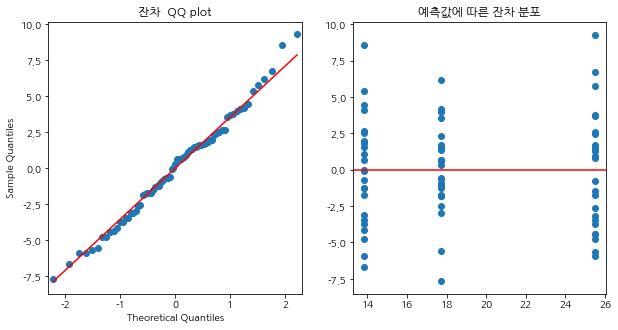

In [70]:
from scipy.stats import shapiro, levene
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm

df1['resid'] = model.resid
gr = [group['resid'].values for name, group in df1.groupby(['Drug'])]

stat1, p1 = shapiro(model.resid)
stat2, p2 = levene(*gr)

print(f"잔차의 정규성 검정: {p1:.3f} 정규성", "만족" if p1 >= 0.05 else "불만족")
print(f"잔차의 등분산 검정: {p2:.3f} 등분산성", "만족" if p2 >= 0.05 else "불만족")
print(f"잔차의 독립성 검정: {durbin_watson(model.resid):.3f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

sm.qqplot(model.resid, line='s', ax=ax[0])
ax[1].scatter(model.fittedvalues, model.resid)
ax[0].set_title('잔차  QQ plot')
ax[1].set_title('예측값에 따른 잔차 분포')
ax[1].axhline(y=0, color='r')
plt.show()

정규성, 등분산성을 만족하는 것을 확인할 수 있다. 실험 데이터를 수집하였으므로 독립성은 만족하는 것으로 한다.  
다음으로 어느 약이 얼마만큼의 혈압강하 효과가 있는지 확인하기 위해 사후검정을 실시한다.  
사후검정기법으로는 Tukey HSD를 사용한다.(중간수준의 민감도)

    Multiple Comparison of Means - Tukey HSD, FWER=0.05     
    group1     group2  meandiff p-adj  lower   upper  reject
------------------------------------------------------------
ACE_inhibitor      ARB   3.8676 0.0009 1.4215  6.3137   True
ACE_inhibitor New_drug  11.6188   -0.0 9.1728 14.0649   True
          ARB New_drug   7.7512    0.0 5.3051 10.1973   True
------------------------------------------------------------


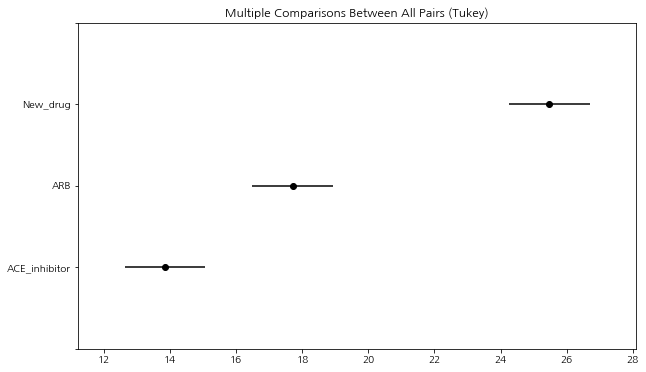

In [72]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

rs = pairwise_tukeyhsd(endog=df1['BP_Reduction'], groups=df1['Drug'], alpha=0.05)

print(rs)

rs.plot_simultaneous()
plt.show()

사후검정 결과, 3그룹 모두 다른 그룹 간의 평균의 차이가 통계적으로 유의한 것을 확인할 수 있다.(rejected: True)  
특히 다른 약에 비해 신약의 평균차이가 아주 크며, 혈압강화값 크기가 큰 것을 보면 신약의 효과가 뛰어남을 알 수 있다. 

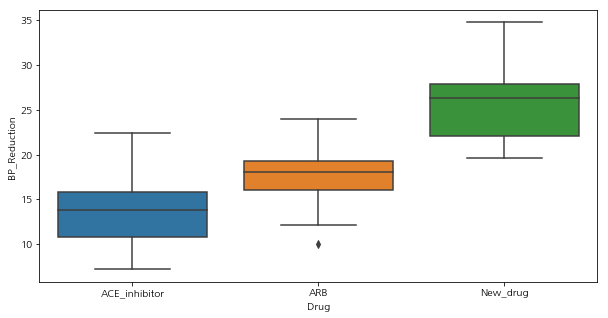

In [77]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df1, x='Drug', y='BP_Reduction')
plt.show()

## 2. 이원배치(two-way ANOVA)

### 1. 정의와 특징  
**이원배치 분산분석(Two-way ANOVA)** 은 **두 개의 독립변수(요인)** 가 동시에 종속변수에 미치는 영향을 검정하는 통계 기법
- **독립변수**: 2개 (범주형/질적 변수)  
- **종속변수**: 1개 (연속형/양적 변수)  
- **목적**:  
  1. 각 요인의 주효과(main effect) 검정  
  2. 두 요인 간 상호작용 효과(interaction effect) 검정  
- **왜 분산분석?**: 요인별 분산 비율(F값)을 이용하여 평균 차이 및 상호작용 유의성을 평가

#### 종류  
- **균형 설계(Balanced design)**: 모든 요인 수준 조합에 동일한 표본 수  
- **비균형 설계(Unbalanced design)**: 일부 조합에 서로 다른 표본 수  

### 2. 기본 가정(Assumptions)  
Two-way ANOVA는 다음 가정을 만족해야 합니다

| 가정                        | 설명                                          | 확인 방법               |
|:---------------------------|:---------------------------------------------|:-------------------------|
| **독립성(Independence)**       | 모든 관찰값이 서로 독립적이어야 함               | 무작위 표집, 설계 단계 확보 |
| **정규성(Normality)**         | 각 요인 조합(cell) 내 종속변수가 정규분포를 따름 | Shapiro–Wilk 검정, Q–Q plot |
| **등분산성(Homogeneity of variance)** | 모든 cell의 분산이 동일해야 함                  | Levene 검정, Bartlett 검정  |

> - **가정 위배 시 대안**:  
>   - 정규성 위배 → 비모수 Kruskal–Wallis 다중비교  
>   - 등분산성 위배 → Welch ANOVA 또는 변환(transform)

#### 가설 설정  

- **요인 A/B 주효과**  
  - H0: 각 독립변수 수준 간 차이없음
  - H1: 각 독립변수 수준 간 차이있음
- **상호작용**  
  - H0: 요인 A, B간 상호작용 없음
  - H1: 요인 A, B간 상호작용 있음

### 4. 사후검정(Post-hoc Tests)  
상호작용 또는 주효과가 유의할 때, 어떤 수준 간 차이가 있는지 확인하기 위해 사후검정을 수행


| 검정법       | 특징                                           | 적용 상황                               |
|:-------------|:----------------------------------------------|:-----------------------------------------|
| **Tukey HSD**    | 모든 수준 쌍 비교, 중간 수준의 보수성           | 균형 설계, 일반적 목적                 |
| **Bonferroni**   | 매우 보수적 (α/m 적용)                         | 비교 수가 많지 않을 때                 |
| **Scheffé**      | 가장 보수적, 모든 대비 대비                   | 대비 패턴이 복잡할 때                   |
| **Duncan MRT**   | 덜 보수적, 민감도 높음                         | 사회과학 등 민감한 비교 필요 시         |

> - **민감도 순서**: Scheffé < Tukey < Duncan (보수적 ←→ 민감)

## 5. 실제 분석 절차  
1. 데이터 준비 및 탐색적 분석  
2. 가정 검토 (정규성, 등분산성)  
3. Two-way ANOVA 실시  
4. F값과 p-값 해석 (요인별 주효과 및 상호작용)  
5. 유의한 효과에 대해 사후검정 수행  
6. 결과 해석 및 보고  

# 문제2: 연령과 약에 따라 혈압강하의 효과가 있는가? 

<가설설정>  
- 주효과 1: (귀무) 연령그룹에 따라 혈압강하의 차이가 없다. / (대립) 연령그룹에 따라 혈합강하의 차이가 없다.  
  주효과 2: (귀무) 약에 따라 혈압 강하의 차이가 없다. / (대립) 약에 따라 혈압 강하의 차이가 있다.  
- 교호작용: (귀무) 연령그룹과 약 종류 간 상호작용이 없다. / (대립) 연령그룹과 약 종류 간 상호작용이 있다.   

In [82]:
df2 = df.copy()

print(f"연령 그룹: {df2['Age_Group'].nunique()} / {df2['Age_Group'].value_counts().values}")
print(f"약 그룹: {df2['Drug'].nunique()} / {df2['Drug'].value_counts().values}")

연령 그룹: 2 / [75 75]
약 그룹: 3 / [50 50 50]


In [84]:
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

model = smf.ols(formula='BP_Reduction~C(Drug)*C(Age_Group)', data=df2).fit()

#교호작용 확인을 위해
two_anova = anova_lm(model, typ=3)
print("<이원배치 ANOVA>")
display(two_anova)

<이원배치 ANOVA>


,sum_sq,df,F,PR(>F)
Intercept,4795.729389,1.0,332.840114,2.871142e-39
C(Drug),1750.313369,2.0,60.738884,7.448556e-20
C(Age_Group),78.392305,1.0,5.440696,2.105810e-02
C(Drug):C(Age_Group),196.589291,2.0,6.821986,1.476824e-03
Residual,2074.825126,144.0,NaN,NaN


교호작용과 두 주성분의 p-value가 0.05보다 작으므로 유의수준 5% 하에서 귀무가설을 기각한다.  

교호작용이 유의하므로 나이그룹과 약 그룹 간 서로 상호작용이 있다. 교호작용이 있다는 것은 "한 변수의 효과가 다른 변수 수준에 따라   
달라진다"는 의미이기 때문이다.  

따라서 한 독립변수의 특정 수준에서 다른 독립변수가 종속변수에 미치는 영향의 효과를 확인하기 위해(교호작용의 구체적 패턴을 확인하기  
위해, "조건을 고정하고 분석하는 방법"인 단순 주효과 분석을 수행한다.  

단순 주효과 검정 전, 우선 분산분석의 가정사항을 만족하는지 확인하기 위해 잔차분석을 실시한다.

잔차의 정규성 검정: 0.970 정규성 만족
잔차의 등분산 검정: 0.722 등분산성 만족
잔차의 독립성 검정: 2.205


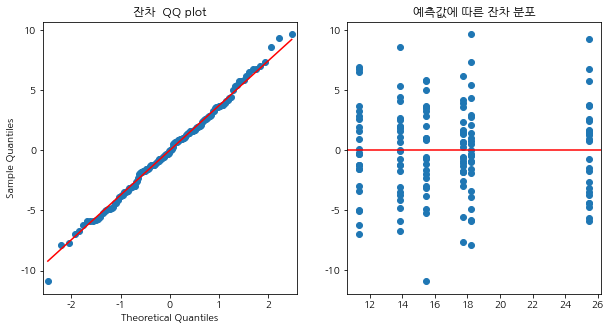

In [88]:
from scipy.stats import shapiro, levene
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm

df2['resid'] = model.resid
gr = [group['resid'].values for name, group in df2.groupby(['Drug', 'Age_Group'])]

stat1, p1 = shapiro(model.resid)
stat2, p2 = levene(*gr)

print(f"잔차의 정규성 검정: {p1:.3f} 정규성", "만족" if p1 >= 0.05 else "불만족")
print(f"잔차의 등분산 검정: {p2:.3f} 등분산성", "만족" if p2 >= 0.05 else "불만족")
print(f"잔차의 독립성 검정: {durbin_watson(model.resid):.3f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

sm.qqplot(model.resid, line='s', ax=ax[0])
ax[1].scatter(model.fittedvalues, model.resid)
ax[0].set_title('잔차  QQ plot')
ax[1].set_title('예측값에 따른 잔차 분포')
ax[1].axhline(y=0, color='r')
plt.show()

정규성, 등분산성을 만족하는 것을 확인할 수 있다. 실험 데이터를 수집하였으므로 독립성은 만족하는 것으로 한다.  
다음으로 각 독립변수의 주효과를 확인하기 위해 각 독립변수의 효과를 통제한 상태에서 단순 주효과 검정을 실시한다.
사후검정기법으로는 Tukey HSD를 사용한다.(중간수준의 민감도)  
- 총 6개의 그룹이므로 데이터 전처리를 통해 약-연령 그룹을 6개로 생성 후 사후검정을 실시한다.

                   Multiple Comparison of Means - Tukey HSD, FWER=0.05                    
           group1                   group2         meandiff p-adj   lower    upper  reject
------------------------------------------------------------------------------------------
Middle_aged - ACE_inhibitor      Middle_aged - ARB   3.8676 0.0057   0.7665  6.9688   True
Middle_aged - ACE_inhibitor Middle_aged - New_drug  11.6188   -0.0   8.5177   14.72   True
Middle_aged - ACE_inhibitor  Young - ACE_inhibitor  -2.5043  0.188  -5.6054  0.5969  False
Middle_aged - ACE_inhibitor            Young - ARB   1.5741 0.6863   -1.527  4.6753  False
Middle_aged - ACE_inhibitor       Young - New_drug   4.3664 0.0011   1.2652  7.4675   True
          Middle_aged - ARB Middle_aged - New_drug   7.7512    0.0   4.6501 10.8524   True
          Middle_aged - ARB  Young - ACE_inhibitor  -6.3719    0.0  -9.4731 -3.2708   True
          Middle_aged - ARB            Young - ARB  -2.2935 0.2748  -5.3946  0.8077  False

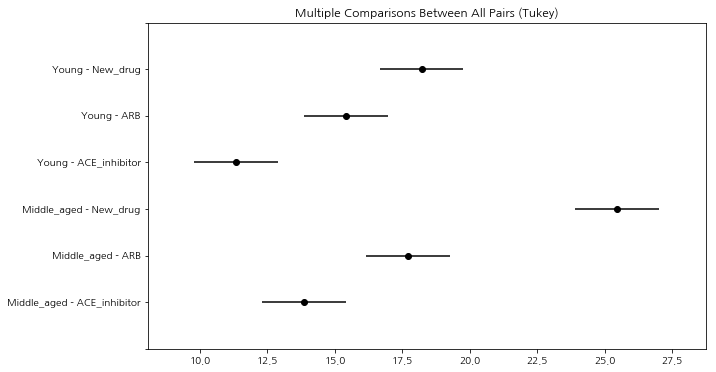

In [92]:
df2['group'] = df2['Age_Group']+' - '+df2['Drug']

from statsmodels.stats.multicomp import pairwise_tukeyhsd

rs = pairwise_tukeyhsd(endog=df2['BP_Reduction'], groups=df2['group'], alpha=0.05)

print(rs)

rs.plot_simultaneous()
plt.show()

단순 주효과 검정결과, 다음의 쌍에서는 귀무가설을 기각할 수 없어 평균의 차이가 없었다.(효과가 없다.)  
- (중년-ACE), (청년-ACE)  / (중년-ACE), (청년- ARB) / (중년- ARB), (청년-ARB)
- (청년- 신약), (청년-ARB) /  (중년- ARB), (청년-신약)

따라서 다음의 사실을 알 수 있다.  

신약은 중년층에서 큰 효과를 볼 수 있다.(효과크기: ACE < ARB < 신약)  
청년의 경우 ARB와 신약의 효과가 통계적으로 차이가 있다고 할 수 없다.(효과크기: ACE < ARB = 신약)    
연령에 관계없이 ACE, ARB의 효과는 차이가 없다.

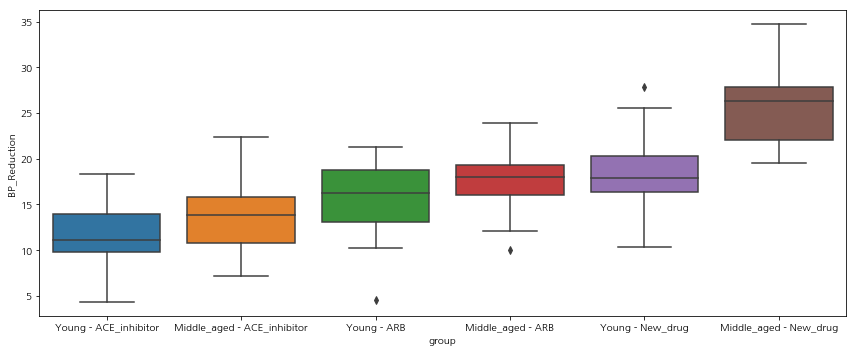

In [97]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df2, x='group', y='BP_Reduction')
plt.tight_layout()
plt.show()

## 3. 다차원배치 분산분석(Multi-way ANOVA)

### 1. 정의와 특징  
**다차원배치 분산분석(Multi-way ANOVA)** 은 **세 개 이상의 독립변수(요인)** 가 종속변수에 미치는 주효과와 다중 교호작용을 동시에 검정하는 통계 기법
- **독립변수**: 3개 이상 (범주형/질적 변수)  
- **종속변수**: 1개 (연속형/양적 변수)  
- **목적**:  
  1. 각 요인의 주효과(main effects) 검정  
  2. 2차 교호작용(two-way interactions) 및 3차 이상 고차 교호작용(high-order interactions) 검정  
- **왜 다차원 ANOVA?**: 요인 수가 많을수록 단일·이원 ANOVA로는 교호작용 구조를 모두 포착할 수 없기 때문

### 2. 기본 가정(Assumptions)  
Multi-way ANOVA는 다음 가정을 만족해야 함

| 가정                        | 설명                                          | 확인 방법                    |
|:---------------------------|:---------------------------------------------|:------------------------------|
| **독립성(Independence)**       | 모든 관찰값이 서로 독립적이어야 함               | 무작위 표집 및 설계 단계 확보   |
| **정규성(Normality)**         | 각 요인 수준 조합(cell) 내 종속변수가 정규분포  | Shapiro–Wilk 검정, Q–Q plot    |
| **등분산성(Homogeneity of variance)** | 모든 cell의 분산이 동일해야 함                  | Levene 검정, Bartlett 검정     |

> - 가정 위배 시:  
>   - 정규성 위배 → 비모수 Kruskal–Wallis 다중비교 등  
>   - 등분산성 위배 → 변환(transform) 또는 Welch ANOVA  

#### 가설 설정  
- **주효과 각각**: 각 독립변수 수준간 차이 여부
- **2차 교호작용**: 두 독립변수 간 상호작용 여부(A*B, A*C, B*C)
- **3차 교호작용**: 모든 독립변수 간 상호작용 여부(A*B*C)

### 4. 사후검정(Post-hoc Tests)  
주효과 또는 교호작용이 유의할 때, 각 수준 간 차이를 확인하기 위해 다중비교를 실시합니다.  

| 검정법       | 특징                                        | 적용 상황                         |
|:-------------|:-------------------------------------------|:-----------------------------------|
| **Tukey HSD**    | 모든 수준 쌍 비교, 중간 보수성              | 균형 설계, 주효과 다중비교         |
| **Bonferroni**   | 매우 보수적 (α/m 적용)                      | 비교 수가 많지 않을 때             |
| **Scheffé**      | 가장 보수적                                 | 모든 대비 고려 시                 |
| **Dunnett**      | 대조군 대비, 보수적                         | 하나의 기준군(control) 대비 분석  |

> - **교호작용 사후비교**:  
>   요인 A×B 교호작용 유의 → 각 A 수준 내에서 B 수준 간 Tukey HSD 등 수행

### 5. 실제 분석 절차  
1. 데이터 준비 및 탐색적 분석  
2. 가정 검토 (정규성, 등분산성)  
3. Multi-way ANOVA 실시 (주효과·모든 교호작용 포함)  
4. F값과 p-값 해석  
5. 유의한 주효과·교호작용에 대해 사후검정 수행  
6. 결과 해석 및 보고  

In [101]:
# -------------------------------
# Multi-way ANOVA용 혈압 감소량 데이터 생성 코드
# 독립변수 3개: Drug, Age_Group, Gender
# 종속변수: BP_Reduction
# -------------------------------

np.random.seed(42)
n_per_combination = 20

# 독립변수 수준 정의
drugs = ['ACE_inhibitor', 'ARB', 'New_drug']
age_groups = ['Young', 'Middle_aged']
genders = ['Male', 'Female']

# 모든 조합의 환자 수
records = []
pid = 1

for drug in drugs:
    for age in age_groups:
        for gender in genders:
            for i in range(n_per_combination):
                # 기본 효과
                if drug == 'ACE_inhibitor':
                    base = 12
                elif drug == 'ARB':
                    base = 15
                else:
                    base = 18
                # 연령대 효과
                age_eff = 3 if age == 'Middle_aged' else 0
                # 성별 효과 (여성이 약간 더 반응한다고 가정)
                gender_eff = 1.5 if gender == 'Female' else 0
                # 교호작용: New_drug × Middle_aged
                interact = 5 if (drug == 'New_drug' and age == 'Middle_aged') else 0
                # 개인차 및 오차
                indiv = np.random.normal(0, 4)
                total = base + age_eff + gender_eff + interact + indiv
                reduction = max(0, total)
                records.append({
                    'Patient_ID': pid,
                    'Drug': drug,
                    'Age_Group': age,
                    'Gender': gender,
                    'BP_Reduction': round(reduction, 1)
                })
                pid += 1

df_multi = pd.DataFrame(records)

# 결과 확인
display(df_multi.head())
print("\n총 관찰치:", len(df_multi))
print("조합 수준 수:", len(df_multi.groupby(['Drug','Age_Group','Gender']))) #3*2*2 = 12


,Patient_ID,Drug,Age_Group,Gender,BP_Reduction
0,1,ACE_inhibitor,Young,Male,14.0
1,2,ACE_inhibitor,Young,Male,11.4
2,3,ACE_inhibitor,Young,Male,14.6
3,4,ACE_inhibitor,Young,Male,18.1
4,5,ACE_inhibitor,Young,Male,11.1



총 관찰치: 240
조합 수준 수: 12


## 문제3: 연령과 약, 성별에 따라 혈압강하의 효과가 있는가? 

<가설설정>  
- 주효과 1: (귀무) 연령그룹에 따라 혈압강하의 차이가 없다. / (대립) 연령그룹에 따라 혈합강하의 차이가 없다.  
  주효과 2: (귀무) 약에 따라 혈압 강하의 차이가 없다. / (대립) 약에 따라 혈압 강하의 차이가 있다.  
  주효과 3: (귀무) 성별에 따라 혈압 강하의 차이가 없다. / (대립) 성별에 따라 혈압 강하의 차이가 있다.  
- 교호작용1: (귀무) 연령그룹과 약 종류 간 상호작용이 없다. / (대립) 연령그룹과 약 종류 간 상호작용이 있다.   
             (귀무) 연령 그룹과 성별 간 상호작용이 없다. / (대립) 연령그룹과 성별 간 상호작용이 있다. 
             (귀무) 약 종류와 성별 간 상호작용이 없다. / (대립) 약 종류와 성별 간 상호작용이 있다.
- 교호작용2: (귀무) 연령그룹-약-성별 간 상호작용이 없다. / (대립) 연령그룹-약-성별 간 상호작용이 있다.

In [102]:
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

model = smf.ols(formula='BP_Reduction~C(Drug)*C(Age_Group)*C(Gender)', data=df_multi).fit()

#교호작용 확인을 위해
multi_anova = anova_lm(model, typ=3)
print("<다차원 배치 ANOVA>")
display(multi_anova)

<다차원 배치 ANOVA>


,sum_sq,df,F,PR(>F)
Intercept,5362.812500,1.0,352.952778,3.326709e-48
C(Drug),1260.282333,2.0,41.472656,4.351061e-16
C(Age_Group),155.236000,1.0,10.216836,1.588760e-03
C(Gender),22.052250,1.0,1.451366,2.295579e-01
C(Drug):C(Age_Group),183.333500,2.0,6.033035,2.798101e-03
C(Drug):C(Gender),33.690167,2.0,1.108657,3.317742e-01
C(Age_Group):C(Gender),0.684500,1.0,0.045050,8.321012e-01
C(Drug):C(Age_Group):C(Gender),0.003583,2.0,0.000118,9.998821e-01
Residual,3464.263000,228.0,NaN,NaN


먼저 주효과 해석의 신뢰성을 확보하기 위해 교호작용부터 확인한다.  
- 약-연령: 상호작용 있음(귀무가설 기각)
- 약-성별: 상호작용 없음
- 나이-성별: 상호작용 없음
- 약-연령-나이: 상호작용 없음

주효과 해석은  
- 약: 종류별 혈압강하의 차이가 있음(귀무가설 기각)
- 연령: 연령별로 혈압강하 차이가 있음
- 성별: 성별 간 혈압강하 차이가 없음(귀무가설 기각x)

약-연령 독립변수 간에만 상호작용이 있으므로 성별에 대한 주효과 검정은 모델검정결과를 해석하고,  
약-성별 독립변수의 주효과에 대한 검정은 이원배치 분산분석과 마찬가지로 각 변수효과를 통제한 상태에서 단순 주효과 분석을 실시  

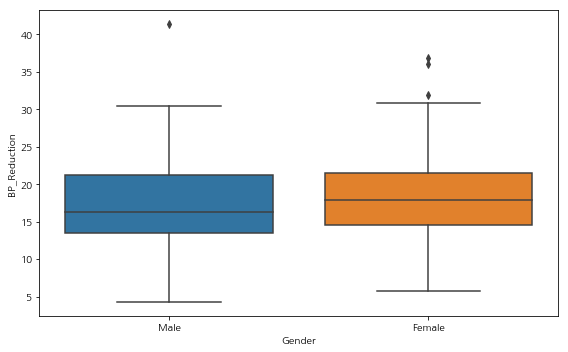

In [117]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_multi, x='Gender', y='BP_Reduction')
plt.tight_layout()
plt.show()

잔차의 정규성 검정: 0.167 정규성 만족
잔차의 등분산 검정: 0.786 등분산성 만족
잔차의 독립성 검정: 2.178


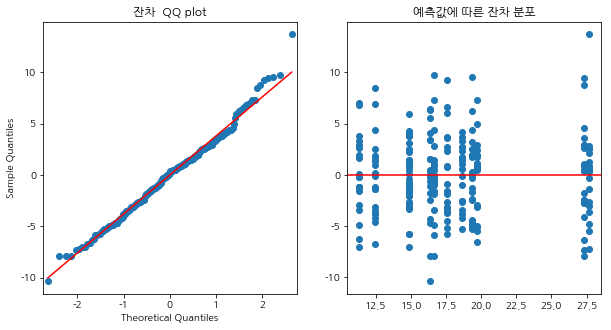

In [113]:
from scipy.stats import shapiro, levene
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm

df_multi['resid'] = model.resid
gr = [group['resid'].values for name, group in df_multi.groupby(['Drug', 'Age_Group', 'Gender'])]

stat1, p1 = shapiro(model.resid)
stat2, p2 = levene(*gr)

print(f"잔차의 정규성 검정: {p1:.3f} 정규성", "만족" if p1 >= 0.05 else "불만족")
print(f"잔차의 등분산 검정: {p2:.3f} 등분산성", "만족" if p2 >= 0.05 else "불만족")
print(f"잔차의 독립성 검정: {durbin_watson(model.resid):.3f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

sm.qqplot(model.resid, line='s', ax=ax[0])
ax[1].scatter(model.fittedvalues, model.resid)
ax[0].set_title('잔차  QQ plot')
ax[1].set_title('예측값에 따른 잔차 분포')
ax[1].axhline(y=0, color='r')
plt.show()

                    Multiple Comparison of Means - Tukey HSD, FWER=0.05                    
           group1                   group2         meandiff p-adj   lower    upper   reject
-------------------------------------------------------------------------------------------
Middle_aged - ACE_inhibitor      Middle_aged - ARB   2.9875 0.0097   0.4737   5.5013   True
Middle_aged - ACE_inhibitor Middle_aged - New_drug  11.8725   -0.0   9.3587  14.3863   True
Middle_aged - ACE_inhibitor  Young - ACE_inhibitor   -3.755 0.0004  -6.2688  -1.2412   True
Middle_aged - ACE_inhibitor            Young - ARB    0.155    1.0  -2.3588   2.6688  False
Middle_aged - ACE_inhibitor       Young - New_drug     3.38  0.002   0.8662   5.8938   True
          Middle_aged - ARB Middle_aged - New_drug    8.885   -0.0   6.3712  11.3988   True
          Middle_aged - ARB  Young - ACE_inhibitor  -6.7425    0.0  -9.2563  -4.2287   True
          Middle_aged - ARB            Young - ARB  -2.8325 0.0171  -5.3463  -0.

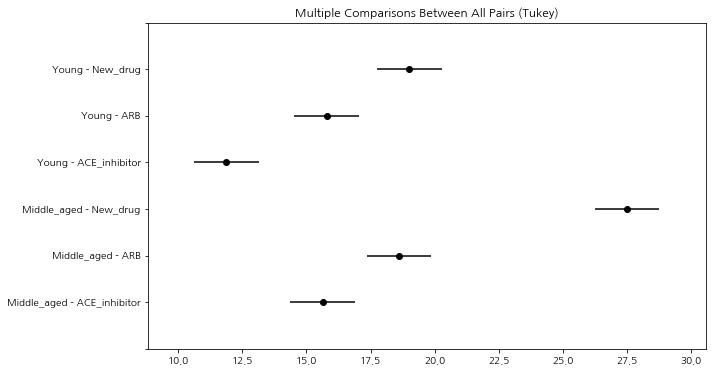

In [114]:
df_multi['group'] = df_multi['Age_Group']+' - '+df_multi['Drug']

from statsmodels.stats.multicomp import pairwise_tukeyhsd

rs = pairwise_tukeyhsd(endog=df_multi['BP_Reduction'], groups=df_multi['group'], alpha=0.05)

print(rs)

rs.plot_simultaneous()
plt.show()

단순 주효과 검정결과, 다음의 쌍에서는 귀무가설을 기각할 수 없어 평균의 차이가 없었다.(효과가 없다.)  
- (중년-ACE), (청년-ACE)  / (중년-ACE), (청년- ARB) / (중년- ARB), (청년-ARB)
- (청년- 신약), (청년-ARB) /  (중년- ARB), (청년-신약)

따라서 다음의 사실을 알 수 있다.  

신약은 중년층에서 큰 효과를 볼 수 있다.(효과크기: ACE < ARB < 신약)  
청년의 경우 ARB와 신약의 효과가 통계적으로 차이가 있다고 할 수 없다.(효과크기: ACE < ARB = 신약)    
연령에 관계없이 ACE, ARB의 효과는 차이가 없다.

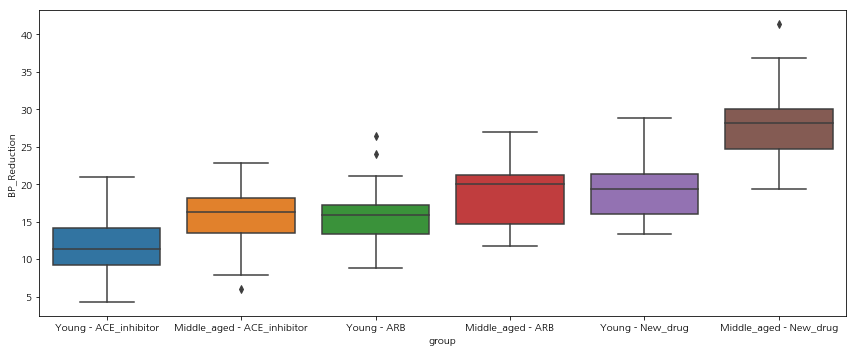

In [118]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df_multi, x='group', y='BP_Reduction')
plt.tight_layout()
plt.show()

## 4. 반복측정 분산분석(Repeated Measures ANOVA)

### 1. 정의와 특징  
**반복측정 분산분석(Repeated Measures ANOVA)** 은 **동일한 피험자(또는 실험 단위)가 여러 시점 또는 조건에서 반복 측정된 자료**를 분석하는 기법
- **독립변수(요인)**: 1개 이상, 모두 **within-subjects factors** (피험자 내 요인)  
- **종속변수**: 1개 (연속형)  
- **목적**:  
  1. 반복 측정 요인의 주효과(main effect) 검정  
  2. 고차원 교호작용(interaction) 검정(이원 이상 설계 시)  
- **장점**:  
  - 피험자 간 변동 제거 → 통계적 검정력 향상  
  - 소표본에서도 높은 민감도 확보  

### 2. 기본 가정(Assumptions)  
| 가정                        | 설명                                          | 확인 방법                    |
|:---------------------------|:---------------------------------------------|:------------------------------|
| **정규성(Normality)**         | 각 수준(cell) 내 잔차가 정규분포를 따름         | Shapiro–Wilk 검정, Q–Q plot    |
| **구형성(Sphericity)**       | 수준 간 차이의 분산이 동일(공분산 행렬이 구형)   | Mauchly’s 검정                 |
| **독립성(Independence)**       | 반복 측정 간 오차가 독립적이어야 함            | 설계 단계에서 확보             |

> - **구형성 위배 시**: Greenhouse–Geisser 또는 Huynh–Feldt 보정 적용  

### 3. 모형
#### 일원 반복측정 ANOVA 모형  
- 독립변수: 1개(within)

#### 이원 이상 반복측정 ANOVA 모형  
| 설계 유형 | 설명                                  |
|:----------|:-------------------------------------|
| 이원 반복측정 ANOVA | 두 개의 within 요인 동시 검정 (예: 시간×조건) |
| 혼합 설계 ANOVA     | between 요인 1개 + within 요인 1개 이상      |
| 이원 혼합반복 ANOVA | between 두 요인 + within 요인 1개 이상      |

### 4. 사후검정(Post-hoc Tests)  
반복측정 ANOVA가 유의할 때, **구체적 수준 차이**를 확인하기 위해 사후비교를 수행
- **Bonferroni**: 보수적, 각 비교 α/m 적용  
- **Tukey HSD**: 수준 쌍별 비교  
- **Dunnett**: 기준 수준(control) 대비 비교  

> - **구형성 위배 시**: 보정된 자유도 및 p-값 사용 후 사후검정  

### 5. 분석 절차  
1. 데이터 준비 및 결측치 처리  
2. 가정 검토  
   - 정규성 → Shapiro–Wilk  
   - 구형성 → Mauchly’s 검정 → 필요시 ε 보정  
3. 반복측정 ANOVA 실시 (e.g. `statsmodels.AnovaRM`, `R::aov()` 등)  
4. F값, 보정 여부, p-값 해석  
5. 사후검정으로 수준 간 차이 확인  
6. 결과 해석 및 시각화  

### 6. 해석 예시  
- **일원 반복측정 ANOVA**:  
  - $$F(2, 38)=5.67$$, ε(GG)=0.88, p=0.007 → 세 수준 간 유의한 차이  
- **이원 반복측정 ANOVA** (요인 A×요인 B):  
  - 요인 A 주효과 $F_A=4.12$, p=0.03  
  - 요인 B 주효과 $F_B=1.45$, p=0.24  
  - 상호작용 $F_{AB}=6.78$, p=0.002 → A 수준별 B 효과 차이 존재  

> **결론**: 보정된 구형성 지수(ε)를 적용해도 주효과와 교호작용이 유의함. 이후 Bonferroni 사후검정으로 세부 차이 분석 필요

# 학습법이 학업 성취도에 미치는 영향

**【연구 배경】**
한국의 한 고등학교에서 세 가지 다른 학습법의 효과를 비교하고자 합니다.
- 전통적 강의법 (Traditional)
- 문제 중심 학습법 (PBL: Problem-Based Learning)
- 플립드 러닝 (Flipped Learning)

각 학습법을 12주간 적용하여 4주, 8주, 12주 시점에서 수학 성취도를 측정

**【연구 설계】**
- 피험자: 90명의 고등학생 (각 그룹 30명)
- 측정 시점: 사전(0주), 4주, 8주, 12주
- 종속변수: 수학 성취도 점수 (0-100점)

In [145]:
# 반복측정 데이터 생성
np.random.seed(42)
n_per_group = 30
time_points = ['Week_0', 'Week_4', 'Week_8', 'Week_12']
methods = ['Traditional', 'PBL', 'Flipped']
# 현실적인 학습 곡선 시뮬레이션
data_education = []
for student_id in range(1, n_per_group * 3 + 1):
    method = methods[(student_id - 1) // n_per_group]
    baseline_ability = np.random.normal(65, 12) # 개인별 기본 능력
    for time_idx, time_point in enumerate(time_points):
    # 시간에 따른 기본 향상
        time_effect = time_idx * 2 # 시간당 2점씩 향상
        # 학습법별 효과 (시간에 따라 증가)
        if method == 'Traditional':
            method_effect = time_idx * 1.5 # 완만한 향상
        elif method == 'PBL':
            method_effect = time_idx * 2.5 # 중간 향상
        else: # Flipped
            method_effect = time_idx * 3.2 # 가장 큰 향상
        # 개인차와 측정 오차
        individual_variation = np.random.normal(0, 5)
        score = baseline_ability + time_effect + method_effect + individual_variation
        score = np.clip(score, 0, 100) # 0-100점 범위 제한
        data_education.append({
        'Student_ID': student_id,
        'Method': method,
        'Time': time_point,
        'Math_Score': score
        })
mix = pd.DataFrame(data_education)

display(mix.groupby(['Student_ID', 'Method', 'Time']).mean())

Math_Score
Student_ID Method      Time               
1          Traditional Week_0    70.269248
                       Week_12   80.289803
                       Week_4    77.699013
                       Week_8    85.575719
2          Traditional Week_0    70.086421
...                                    ...
89         Flipped     Week_8    79.563185
90         Flipped     Week_0    74.869062
                       Week_12   83.340003
                       Week_4    73.536672
                       Week_8    80.866736

[360 rows x 1 columns]

## 문제4: 플립드 러닝 학습법을 적용하였을 때 학습기간에 따른 수학점수 향상효과가 있는가?

<가설설정>  
- 귀무: 학습기간에 따른 수학점수의 평균은 차이가 없다. 
- 대립: 적어도 한 그룹의 학습기간에 따른 수학점수의 평균은 차이가 있다.

In [146]:
df4 = mix.copy()
df4 = df4[df4['Method'] == 'Flipped'].drop(columns='Method')
df4.head()

,Student_ID,Time,Math_Score
240,61,Week_0,52.251155
241,61,Week_4,63.988528
242,61,Week_8,68.503911
243,61,Week_12,70.547552
244,62,Week_0,72.796253


In [148]:
df4.nunique()

Student_ID     30
Time            4
Math_Score    119
dtype: int64

In [154]:
from statsmodels.stats.anova import AnovaRM

rm_model = AnovaRM(df4, 'Math_Score', 'Student_ID', within=['Time']).fit() #데이터셋, 종속변, 식별자, winthin

print(rm_model.summary())

              Anova
     F Value Num DF  Den DF Pr > F
----------------------------------
Time 66.0651 3.0000 87.0000 0.0000



In [158]:
import pingouin as pg

rm_model2 = pg.rm_anova(dv='Math_Score', within='Time', subject='Student_ID',  data=df4, detailed=True)

display(rm_model2)

,Source,SS,DF,MS,F,p-unc,np2,eps
0,Time,4182.590168,3,1394.196723,66.065142,2.338318e-22,0.694946,0.915601
1,Error,1835.992635,87,21.103364,NaN,NaN,NaN,NaN


유의수준 5% 하에서 Time의 p-value가 0.05보다 확연히 작으므로 귀무가설을 기각한다.  
따라서 시간별 수학점수의 차이가 있다는 대립가설은 통계적으로 유의하다.

또한 eps 계수 값이 1에 가까우므로 구형성을 만족한다고 볼 수 있다. 다음으로 잔차의 정규성, 등분산성 여부를 확인하면  
모델의 결과 신뢰여부를 확인할 수 있다.

-----------------------------------------------------------------------------------------------------

| 컬럼       | 설명                                                                                       |
|:----------|:-------------------------------------------------------------------------------------------|
| **Source**   | 효과 이름(요인 혹은 교호작용). `Time`은 반복측정 요인, `Error`는 잔차(오차) 성분입니다.            |
| **SS**       | Sum of Squares(제곱합). 해당 효과가 설명하는 변동의 크기입니다.                                |
| **DF**       | Degrees of Freedom(자유도). 해당 효과에 할당된 자유도 수입니다.                               |
| **MS**       | Mean Square(평균제곱). SS를 DF로 나눈 값(SS/DF)으로, 분산에 해당합니다.                       |
| **F**        | F 통계량. 효과 MS를 Error MS로 나눈 값으로, 효과가 유의한지 판단하는 기준입니다.              |
| **p-unc**    | Uncorrected p-value. 보정되지 않은 p값으로, 귀무가설 기각 여부를 판단합니다.                  |
| **np2**      | Partial eta-squared(부분 η²). 해당 효과가 전체 변동에서 차지하는 비중을 나타내는 효과 크기 지표입니다. |
| **eps GG**   | **Greenhouse–Geisser** ε. 구형성(sphericity) 위배 시 F검정의 자유도를 보정하기 위한 계수입니다.      |
| **eps HF**   | Huynh–Feldt ε. Greenhouse–Geisser ε보다 덜 보수적인 대안 보정 계수입니다.                      |

- **Time** 행: 반복 측정 요인의 변동  
- **Error** 행: 잔차(개인차 + 측정오차) 변동으로, F 통계량 계산의 분모 역할  

위 표에서 `eps GG`와 `eps HF`가 `1`이면 구형성 가정이 충족된 것으로 볼 수 있고, 1보다 작으면 보정된 자유도를 사용하는 것이 권장

**Greenhouse–Geisser ε (ε₍GG₎) 판단 기준**

| ε₍GG₎ 범위            | 구형성 가정 충족 여부            | 처리 방식                       |
|----------------------|---------------------------------|---------------------------------|
| ε₍GG₎ ≥ 0.95         | 거의 완벽 충족                   | 보정 불필요                      |
| 0.75 ≤ ε₍GG₎ < 0.95   | 대체로 충족                       | 보수적 관점: Huynh–Feldt ε₍HF₎ 적용 고려¹ |
| 0.50 ≤ ε₍GG₎ < 0.75   | 일부 위배                          | Greenhouse–Geisser ε₍GG₎ 보정 적용  |
| ε₍GG₎ < 0.50         | 심각하게 위배                      | Greenhouse–Geisser ε₍GG₎ 보정 적용, 비모수 대안 고려² |

¹ ε₍HF₎(Huynh–Feldt 보정)은 ε₍GG₎보다 덜 보수적이어서, ε₍GG₎이 0.75 이상일 때 종종 대안으로 사용  
² ε₍GG₎이 0.50 미만이면 반복측정 ANOVA 가정이 크게 위배된 상태이므로, 비모수 검정(예: Friedman 검정)이나 다중 비교를 고려

In [164]:
from scipy.stats import f

# 1) ε_GG 계산
eps_gg = rm_model2.loc[rm_model2['Source']=='Time', 'eps'].values[0]

# 피험자 수(N)와 시점 수(k)
N = df4['Student_ID'].nunique()
k = df4['Time'].nunique()

# Huynh–Feldt ε 계산
eps_hf = ((N*(k-1)*eps_gg - 2) /
          ((N*(k-1)-2)*eps_gg))

print(f"ε_GG = {eps_gg:.3f} → ε_HF = {eps_hf:.3f}")

# 보정된 자유도 적용한 F-검정 수동 계산
ss_time   = rm_model2.loc[rm_model2['Source']=='Time',  'SS'].values[0]
ss_error  = rm_model2.loc[rm_model2['Source']=='Error', 'SS'].values[0]

df1_hf = (k-1) * eps_hf
df2_hf = (N-1)*(k-1) * eps_hf

ms_time  = ss_time  / df1_hf
ms_error = ss_error / df2_hf

F_hf = ms_time / ms_error
p_hf = 1 - f.cdf(F_hf, df1_hf, df2_hf)

print(f"수정된 F({df1_hf:.2f}, {df2_hf:.2f}) = {F_hf:.3f}, p = {p_hf:.3f}")

ε_GG = 0.916 → ε_HF = 0.998
수정된 F(2.99, 86.82) = 66.065, p = 0.000


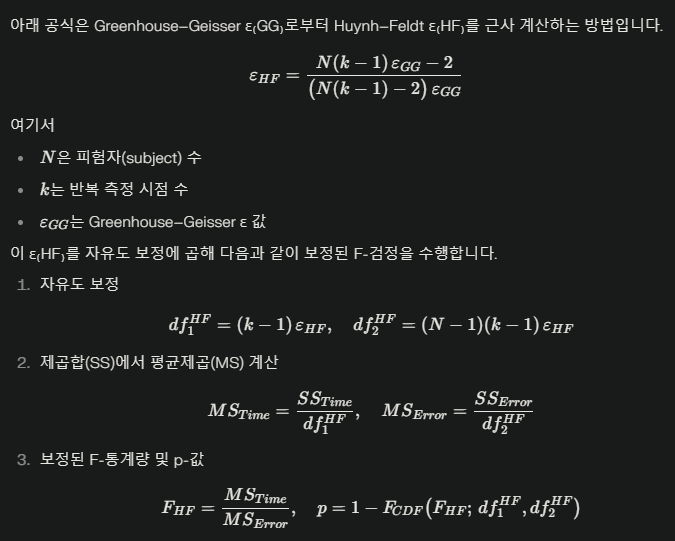

잔차의 정규성 검정: 0.273 정규성 만족


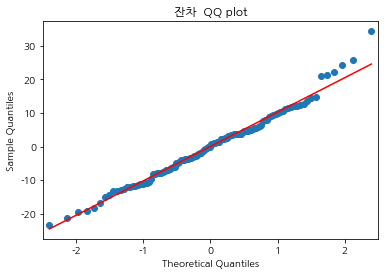

In [170]:
# 반복측정 구조를 단순화하여 OLS로 근사
model = smf.ols('Math_Score ~ C(Time)', data=df4).fit()

from scipy.stats import shapiro
import statsmodels.api as sm

df4['resid'] = model.resid

stat1, p1 = shapiro(model.resid)
print(f"잔차의 정규성 검정: {p1:.3f} 정규성", "만족" if p1 >= 0.05 else "불만족")

sm.qqplot(model.resid, line='s')
plt.title('잔차  QQ plot')
plt.show()

독립성(실험데이터 수집), 구형성, 정규성을 만족하므로 위 모델검정 결과를 신뢰할 수 있다.  
다음으로 각 시간수준별 효과를 검증한다. 사후검정 방식은 마찬가지로 tukey HSD를 사용한다.

  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower    upper  reject
-------------------------------------------------------
 Week_0 Week_12  14.7031    0.0   7.6858 21.7204   True
 Week_0  Week_4   3.7752 0.5005  -3.2421 10.7926  False
 Week_0  Week_8  11.6734 0.0002    4.656 18.6907   True
Week_12  Week_4 -10.9279 0.0005 -17.9452 -3.9105   True
Week_12  Week_8  -3.0297 0.6746 -10.0471  3.9876  False
 Week_4  Week_8   7.8981 0.0208   0.8808 14.9155   True
-------------------------------------------------------


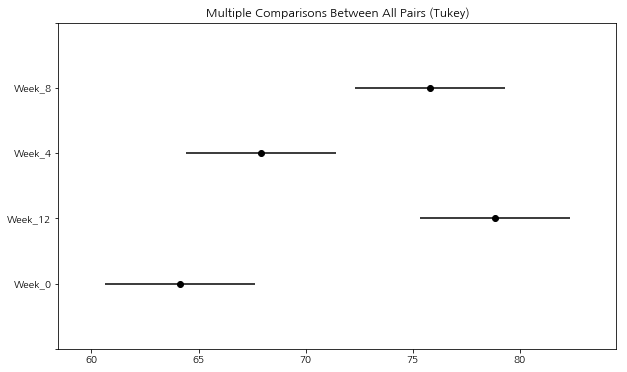

In [171]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

rs = pairwise_tukeyhsd(endog=df4['Math_Score'], groups=df4['Time'], alpha=0.05)

print(rs)

rs.plot_simultaneous()
plt.show()

사후검정 결과, 각 시간 그룹 간 수학점수 평균의 차이여부를 확인할 수 있다.  
- 유의한 차이가 있음: 0 - 12, 0 - 8, 4 - 8, 4 - 12

따라서 해당 학습방법으로 학습을 했을 시, 8시간 이상 학습을 하면 수학성적이 향상되는 효과를 볼 수 있으며  
8시간 이후 추가적인 학습을 했을 때는 유의한 점수차이가 없음을 알 수 있다. 

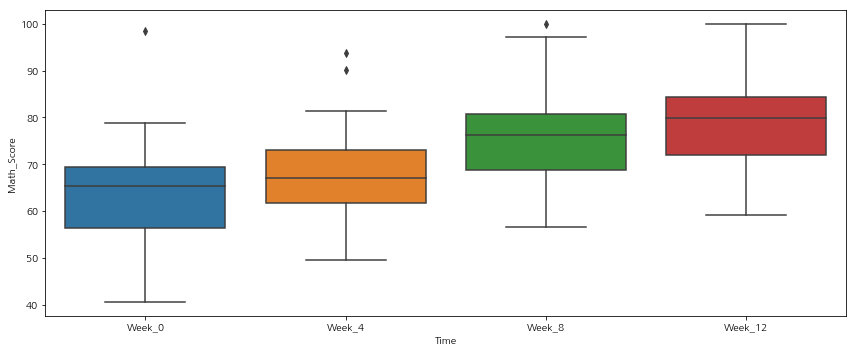

In [172]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df4, x='Time', y='Math_Score')
plt.tight_layout()
plt.show()

## 5. 다변량 분산분석(Multivariate ANOVA, MANOVA)

### 1. 정의와 특징  
**다변량 분산분석(MANOVA)** 은 **하나 이상의 범주형 독립변수(요인)** 가 **두 개 이상의 연속형 종속변수**에 동시에 미치는 영향을 검정하는 기법  
- **독립변수**: 1개 이상 (범주형/질적 변수)  
- **종속변수**: 2개 이상 (연속형/양적 변수)  
- **목적**:  
  1. 각 요인이 종속변수 다변량 벡터에 미치는 **주효과(main effects)** 검정  
  2. 두 개 이상의 요인 간 **교호작용(interaction effects)** 검정  
- **왜 MANOVA?**: 여러 종속변수가 상호 상관될 때, 개별 ANOVA를 각각 수행하면 1종 오류가 누적되고 다변량 구조를 무시하므로,   
  MANOVA는 공분산을 고려해 전체 패턴을 검정한다.

### 2. 기본 가정(Assumptions)  
| 가정                                       | 설명                                           | 확인 방법                         |
|:------------------------------------------|:----------------------------------------------|:----------------------------------|
| **독립성(Independence)**                      | 모든 관찰값이 서로 독립적이어야 함               | 무작위 표집, 설계 단계 확보         |
| **정규성(Multivariate Normality)**          | 각 그룹 내 종속변수 벡터가 다변량 정규분포       | Shapiro–Wilk on residuals, Mardia 검정 |
| **등분산공분산성(Homogeneity of Covariance)** | 각 그룹 간 종속변수 공분산 행렬이 동일해야 함    | Box’s M 검정                       |
| **선형성(Linearity)**                        | 종속변수 간 관계는 선형이어야 함                 | 산점도 행렬(matrix scatterplot)    |
| **다중공선성 불가(Multicollinearity)**       | 종속변수들 간 과도한 상관 피해야 함               | VIF, 상관계수 확인                 |

> - **가정 위배 시**:  
>   - 정규성 위배 → 변수 변환(transform) 또는 비모수 다변량 검정  
>   - 등분산공분산성 위배 → 로버스트 MANOVA 기법  

### 3. 가설 설정  
- **주효과 (Factor A)**  
  - 귀무: 모든 그룹의 종속변수 평균 벡터가 동일  
  - 대립: 적어도 한 그룹의 종속변수 벡터가 다름  
- **교호작용 (A×B 등)**  
  - 귀무: A×B 교호작용 효과 없음 (교호작용 평균 벡터 차이 없음)  
  - 대립: 교호작용 효과 있음

### 4. 다변량 검정 통계량 및 사후검정  
#### 주요 다변량 통계량  
- **Wilks’ Lambda**
- **Pillai’s Trace**  
- **Hotelling–Lawley Trace**  
- **Roy’s Largest Root**  

이들은 그룹 간 설명 분산과 오차 분산을 비교해 다변량 F 유사 통계량을 계산한다.

#### 사후검정(Post-hoc Tests)  
MANOVA가 유의할 때,  
1. **개별 종속변수별 ANOVA**로 어떤 변수가 차이를 주도하는지 확인  
2. **다변량 다중비교**: Bonferroni 보정된 다중 t-검정 또는 Tukey 유형 확장  
3. **Canonical Variates 분석**: 그룹 간 구분 축(canonical variates) 해석  

### 5. 실제 분석 절차  
1. **데이터 준비 및 탐색**  
2. **가정 검토**  
   - 다변량 정규성, 공분산 등분산성, 선형성 등  
3. **MANOVA 실행**  
   - Python: `statsmodels.multivariate.MANOVA.from_formula('Y1 + Y2 ~ Factor', data)`  
   - R: `manova(cbind(Y1, Y2) ~ Factor, data)`  
4. **다변량 통계량 해석** (Wilks’ λ, Pillai 등)  
5. **유의 시 사후분석**  
   - 개별 ANOVA  
   - 다중비교 보정  
   - Canonical Variates plot  
6. **결과 보고 및 시각화**

### 6. 해석 예시  
- **MANOVA 결과**: Wilks’ Λ = 0.72, F(4, 112)=3.15, p=0.017 → 종속변수 벡터 전체에 그룹 차이 유의  
- **개별 ANOVA**:  
  - Y1: F(2, 57)=4.8, p=0.012 → 유의  
  - Y2: F(2, 57)=1.9, p=0.16 → 비유의  
- **사후검정 (Bonferroni)**: Y1에서 그룹 A vs B: p=0.03, A vs C: p=0.10, B vs C: p=0.04  
- **Canonical plot**: 첫 번째 canonical variate가 그룹 차이를 잘 설명  

> **결론**: 다변량 수준에서 유의한 그룹 효과가 나타났으며, 주로 종속변수 Y1가 그룹 차이를 주도함.

In [178]:
# 기존 df 복사
df5 = df.copy()

# 재현 가능성 설정
np.random.seed(42)

# 이완기 혈압 감소량 계산
diastolic_reduction = []

for _, row in df5.iterrows():
    drug = row['Drug']
    age = row['Age_Group']
    
    # 기본 수축기 감소량 기반 설정
    if drug == 'ACE_inhibitor':
        base_s = 12
    elif drug == 'ARB':
        base_s = 15
    else:  # New_drug
        base_s = 18

    # 연령대 효과
    if age == 'Middle_aged':
        base_s += 3

    # 교호작용 효과
    if drug == 'New_drug' and age == 'Middle_aged':
        base_s += 5

    # 개인차 및 측정 오차
    indiv = np.random.normal(0, 4)
    total_s = base_s + indiv

    # 비례효과 0.6~0.8
    prop = np.random.uniform(0.6, 0.8)
    diastolic = max(0, total_s * prop + np.random.normal(0, 2))
    diastolic_reduction.append(diastolic)

# 새로운 열 추가
df5['Diastolic_Reduction'] = diastolic_reduction

# 확인
df5 = df5.drop(columns=['Age_Group'])
display(df5.head())
print(f"약 그룹 수준: {df5['Drug'].nunique()} / 분포 {df5['Drug'].value_counts().to_dict()}")

,Patient_ID,BP_Reduction,Drug,Diastolic_Reduction
0,1,13.986857,ACE_inhibitor,10.163244
1,2,11.446943,ACE_inhibitor,5.404921
2,3,14.590754,ACE_inhibitor,12.600389
3,4,18.092119,ACE_inhibitor,5.110495
4,5,11.063387,ACE_inhibitor,5.074429


약 그룹 수준: 3 / 분포 {'ACE_inhibitor': 50, 'New_drug': 50, 'ARB': 50}


## 문제5: 신약이 혈압과 기본 수축기 감소량에 영향을 주는가?

- 귀무: 세 약물그룹간 혈압감소량과 기본 수축기 감소량의 차이가 없다.(평균 벡터가 동일)
- 대립: 세 약물그룹간 혈압감소량과 기본 수축기 감소량의 차이가 있다.(평균 벡터가 차이)

In [190]:
from statsmodels.multivariate.manova import MANOVA

mano1 = MANOVA.from_formula('BP_Reduction + Diastolic_Reduction ~ C(Drug)', data=df5)

print("MANOVA 검정결과")
print(mano1.mv_test())

MANOVA 검정결과
                  Multivariate linear model
                                                              
--------------------------------------------------------------
       Intercept        Value  Num DF  Den DF  F Value  Pr > F
--------------------------------------------------------------
          Wilks' lambda 0.2071 2.0000 146.0000 279.4864 0.0000
         Pillai's trace 0.7929 2.0000 146.0000 279.4864 0.0000
 Hotelling-Lawley trace 3.8286 2.0000 146.0000 279.4864 0.0000
    Roy's greatest root 3.8286 2.0000 146.0000 279.4864 0.0000
--------------------------------------------------------------
                                                              
--------------------------------------------------------------
         C(Drug)         Value  Num DF  Den DF  F Value Pr > F
--------------------------------------------------------------
           Wilks' lambda 0.4799 4.0000 292.0000 32.3829 0.0000
          Pillai's trace 0.5222 4.0000 294.0000 25.9737 0.0000


| 통계량                      | 정의 및 특징                                                                                                           | 해석 요점                                                                                                      |
|:---------------------------|:-----------------------------------------------------------------------------------------------------------------------|:---------------------------------------------------------------------------------------------------------------|
| Wilks’ lambda (Λ)          | 설명 분산 대비 오차 분산의 비율을 나타냄. Λ가 작을수록 그룹 간 차이가 크다는 의미.                                       | Λ값이 0에 가까울수록 집단 차이가 크다.  
유의 p<0.05면 다변량 평균 벡터가 집단별로 다름을 의미.                                             |
| Pillai’s trace (V)         | 그룹 간 분산 설명력의 합. 가장 **강건(robust)** 하여 가정 위배에 덜 민감. V가 클수록 그룹 차이가 큼.                       | V값이 클수록 효과 크기가 크다.  
유의 p<0.05면 다변량 효과 존재.                                                              |
| Hotelling–Lawley trace (T) | 설명 분산과 오차 분산의 비율을 합산한 형태. Wilks’ λ를 대체하는 통계량.                                                    | T값이 클수록 그룹 간 차이가 크다.  
유의 p<0.05면 다변량 평균 벡터 차이 유의.                                                      |
| Roy’s greatest root (Θ)    | 최대 고유값(eigenvalue)에 기반한 통계량. 가장 강력하지만 가정 위배에 민감. 첫 번째 canonical variate 차이에 집중.        | Θ값이 클수록 첫 번째 canonical variate에서 집단 간 차이가 크다.  
유의 p<0.05면 최소 하나의 canonical variate에 유의한 차이 존재. |


- **C(Drug) (신약 효과)**  
   - Wilks’ Λ = 0.4799, F(4,292)=32.38, p<0.001  
   - Pillai V = 0.5222, F(4,292)=25.97, p<0.001  
   - → 세 약물 그룹 간 다변량 평균 벡터 차이가 유의함. 
   - Hotelling T와 Roy’s Θ 역시 모두 p<0.001이므로, 결과가 일관됨
   
따라서, 신약의 종류에 따라 혈압감소량과 기본수축기 감소 차이가 있다는 대립가설을 채택한다.
- Pillai’s trace가 가장 가정 위배에 덜 민감하므로, 가정이 완벽하지 않을 때도 Pillai 결과를 중점적으로 고려할 수 있음
- Roy’s greatest root는 첫 번째 canonical variate(가장 큰 그룹 차이를 설명하는 축)만 평가하므로, 다변량 효과가 한 차원에 집중될 때 민감하게 반응

In [212]:
from scipy.stats import chi2

# 등분산공분산성(Homogeneity of Covariance) 수동구현
def box_m_test(df, group_col, dv_cols):
    # 그룹별 표본 크기 및 공분산 행렬 계산
    groups = df[group_col].unique()
    n_groups = len(groups)
    cov_mats = {}
    ns = {}
    for g in groups:
        data_g = df.loc[df[group_col] == g, dv_cols].values
        ns[g] = data_g.shape[0]
        cov_mats[g] = np.cov(data_g, rowvar=False)

    p = len(dv_cols)  # 변수 수
    # 풀링 공분산 행렬
    pooled_num = sum((ns[g] - 1) * cov_mats[g] for g in groups)
    pooled_den = sum(ns[g] - 1 for g in groups)
    S_pooled = pooled_num / pooled_den

    # Box’s M 통계량 계산
    M = (pooled_den * np.log(np.linalg.det(S_pooled))
         - sum((ns[g] - 1) * np.log(np.linalg.det(cov_mats[g])) for g in groups))

    # 보정 계수 C
    C = 1 - (2*p**2 + 3*p - 1) * (sum(1/(ns[g]-1) for g in groups) - 1/pooled_den) / (6*(p+1)*(n_groups-1))

    # 카이제곱 변환
    chi2_stat = M * C
    df_chi2 = (n_groups - 1) * p * (p + 1) / 2
    p_value = 1 - chi2.cdf(chi2_stat, df_chi2)

    return {
        'Box M': M,
        'Chi-Square': chi2_stat,
        'df': df_chi2,
        'p-value': p_value
    }

1. 다변량 정규성 만족:  (True, 0.7339318624404283)
2. 각 종속변수별 정규성 만족여부
- resid_bp 종속변수(0.984): 정규성 만족
- resid_dia 종속변수(0.469): 정규성 만족
3.등분산 공분산성 위배: 0.009 / 로버스트 다변량 검정 사용고려(공분산동질성 위배에 비교적 강건)
4. 종속변수간 선형성 만족


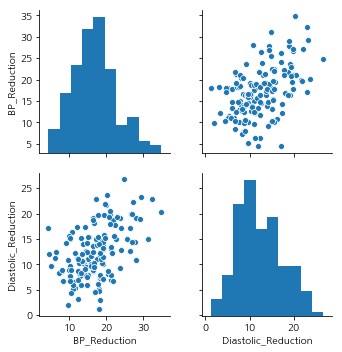

- VIF(BP_Reduction) : 1.30
- VIF(Diastolic_Reduction) : 1.30
5. 종속변수간 다중공선성 미성립


In [224]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.multivariate.manova import MANOVA

#각 종속변수별 one-way anova
model1  = smf.ols('BP_Reduction ~ C(Drug)', data=df5).fit()
model2 = smf.ols('Diastolic_Reduction ~ C(Drug)', data=df5).fit()
o_an1 = sm.stats.anova_lm(model1, typ=2)
o_an2 = sm.stats.anova_lm(model2, typ=2)

#1. Mardia’s Test (다변량 정규성)

resid_df = pd.DataFrame({
    'resid_bp':  model1.resid,
    'resid_dia': model2.resid
})

mardia_results = pg.multivariate_normality(resid_df, alpha=0.05)
print("1. 다변량 정규성 만족: ", mardia_results)

#2. Shapiro–Wilk Test (각 종속변수별)
print("2. 각 종속변수별 정규성 만족여부")
for col in resid_df.columns:
    stat, p = shapiro(resid_df[col])
    print(f"- {col} 종속변수({p:.3f}): 정규성", "만족" if p >= 0.05 else "불만족")

#3. 등분산공분산성(Homogeneity of Covariance): 그룹 간 종속변수 공분산 행렬이 동일해야 함
rs = box_m_test(df5, group_col='Drug',
                    dv_cols=['BP_Reduction','Diastolic_Reduction'])
print(f"3.등분산 공분산성 위배: {rs['p-value']:.3f}", "/ 로버스트 다변량 검정 사용고려(공분산동질성 위배에 비교적 강건)")

#4. 선형성: 종속변수 간 선형 관계가 성립해야 함
print("4. 종속변수간 선형성 만족")
sns.pairplot(df5[['BP_Reduction','Diastolic_Reduction']])
plt.show()

# #5. 다중공선성 불가(Multicollinearity): 종속변수들 간 과도하게 높은 상관(공선성)이 없어야 함
# 다변수 설정
X = df5[['BP_Reduction', 'Diastolic_Reduction']]

# VIF 계산을 위해 상수항 추가
X_with_const = sm.add_constant(X)

# VIF 출력
for i, col in enumerate(X.columns, start=1):  # 0번은 상수항
    vif = variance_inflation_factor(X_with_const.values, i)
    print(f"- VIF({col}) : {vif:.2f}")
print("5. 종속변수간 다중공선성 미성립")

사후검정 또한 각 종속변수 별 생성한 one-way anova 결과를 확인 후 tukey HSD를 사용

<<종속변수 : BP_Reduction >>


,sum_sq,df,F,PR(>F)
C(Drug),2150.688252,2.0,54.9551,1.509716e-18
Residual,2876.449815,147.0,NaN,NaN


약종류에 따라 BP_Reduction 평균차이가 유의, 각 그룹별 효과차이 확인을 위한 사후검정 수행

    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
    group1     group2  meandiff p-adj  lower  upper  reject
-----------------------------------------------------------
ACE_inhibitor      ARB   2.3636 0.0134 0.4068 4.3203   True
ACE_inhibitor New_drug   7.0173    0.0 5.0605 8.9741   True
          ARB New_drug   4.6537    0.0  2.697 6.6105   True
-----------------------------------------------------------


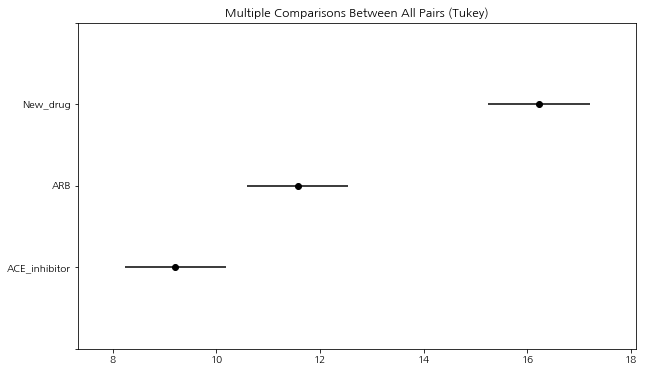

<<종속변수 : Diastolic_Reduction >>


,sum_sq,df,F,PR(>F)
C(Drug),1274.767710,2.0,37.328374,7.767368e-14
Residual,2510.032389,147.0,NaN,NaN


약종류에 따라 Diastolic_Reduction 평균차이가 유의, 각 그룹별 효과차이 확인을 위한 사후검정 수행

    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
    group1     group2  meandiff p-adj  lower  upper  reject
-----------------------------------------------------------
ACE_inhibitor      ARB   2.3636 0.0134 0.4068 4.3203   True
ACE_inhibitor New_drug   7.0173    0.0 5.0605 8.9741   True
          ARB New_drug   4.6537    0.0  2.697 6.6105   True
-----------------------------------------------------------


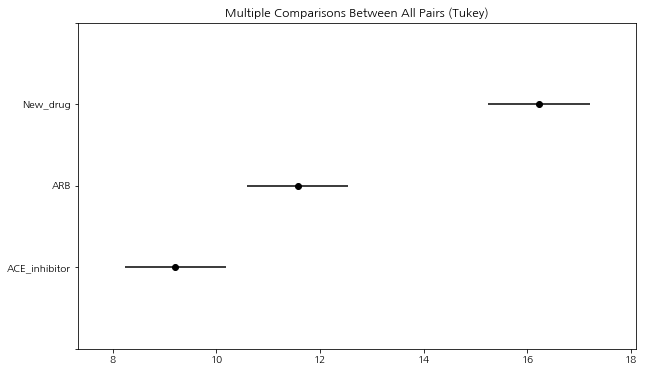

In [235]:
m_list = [[o_an1, 'BP_Reduction'], [o_an2, 'Diastolic_Reduction']]

for model, name in m_list:
    print(f"<<종속변수 : {name} >>")
    display(model)
    
    if(model.iloc[0, 3] < 0.05):
        print(f"약종류에 따라 {name} 평균차이가 유의, 각 그룹별 효과차이 확인을 위한 사후검정 수행\n")
        rs = pairwise_tukeyhsd(endog=df5[col], groups=df['Drug'], alpha=0.05)
        print(rs)
        rs.plot_simultaneous()
        plt.show()

두 종속변수별 약 종류의 효과를 사후검정을 통해 확인하였다. 
두 종속변수 모두 세 종류의 약 종류 간 종속변수 수치 평균 차이가 존재하였으며,  
신약을 사용하였을 때 혈압하강 및 기본수축기 감소가 가장 큰 것을 확인할 수 있다.

## 6. 혼합설계 분산분석(Mixed ANOVA)

### 1. 정의와 특징  
**혼합설계 분산분석(Mixed ANOVA)** 은  
- 하나의 요인은 **집단 간 요인(Between-subjects)** 으로,  
- 다른 요인은 **반복 측정 요인(Within-subjects)** 으로 설정하여  
두 요인 모두가 종속변수에 미치는 주효과와 상호작용을 동시에 검정하는 통계 기법

- **독립변수**  
  - Between-subjects 요인: 그룹 간 비교(예: 치료군 vs 대조군)  
  - Within-subjects 요인: 반복 측정(예: 시간, 조건)  
- **종속변수**: 연속형(양적) 변수  
- **목적**  
  1. Between 요인 주효과 검정  
  2. Within 요인 주효과 검정  
  3. 두 요인의 상호작용 검정  
- **장점**  
  - 반복 측정에서 얻는 통계적 검정력 증가  
  - 집단 간 비교와 반복 측정을 한 번에 처리  

### 2. 기본 가정(Assumptions)  

| 가정                                    | 설명                                                        | 확인 방법                            |
|:---------------------------------------|:-----------------------------------------------------------|:--------------------------------------|
| **독립성(Independence)**                   | Between-subjects 관찰값은 서로 독립적                         | 무작위 배정 및 표집                     |
| **정규성(Normality)**                     | 각 그룹×시점(cell) 내 잔차는 정규분포를 따름                  | Shapiro–Wilk 검정, Q–Q plot             |
| **구형성(Sphericity)** (Within 요인에만)  | 반복 측정 요인 수준 간 차이의 분산(공분산 행렬)이 동일         | Mauchly’s 검정; 위배 시 ε 보정(GG/HF)   |
| **등분산성(Homogeneity of variance)**     | Between 그룹 간 분산이 동일                                   | Levene 검정                             |

> - 구형성 위배 시  
>   - **Greenhouse–Geisser(εGG)** 또는 **Huynh–Feldt(εHF)** 보정 적용  

### 3. 가정:  2-way ANOVA와 동일  

### 4. 사후검정(Post-hoc Tests)  
유의한 주효과나 상호작용에 대해, 구체적 집단 또는 시점 차이를 확인하기 위해 사후검정을 수행합니다:  

| 검정법       | 특징                                       | 적용 상황                               |
|:-------------|:------------------------------------------|:-----------------------------------------|
| **Tukey HSD**    | Between 요인 수준 간 쌍별 비교, 보수적    | Between 주효과가 유의할 때              |
| **Bonferroni**   | 보수적(α/비교수 적용)                      | 비교 수가 많은 경우 또는 선택적 비교    |
| **Simple effects** | 상호작용 유의 시 각 그룹 내 Within 차이 검정 | A×B 상호작용 후 B 수준별 A 효과 분석    |
| **Pairwise t-tests** | ε 보정된 자유도 사용                       | Within 요인 수준 간 비교                |

> - Within 사후검정 시 ε 보정된 p-값 사용  

### 5. 분석 절차  
1. 데이터 준비 및 가정 검토  
   - Between 독립성, Within 정규성·구형성  
2. Mixed ANOVA 실행 (`statsmodels.MixedLM` 또는 `AnovaRM` 등)  
3. 주효과 및 상호작용 F값·p-값 해석  
4. 구형성 위배 시 ε 보정 결과 확인  
5. 사후검정으로 구체적 수준 차이 검토  
6. 결과 정리 및 시각화  

## 문제6: 학습법, 학습기간에 따른 수학점수 향상효과가 있는가?

여기서 학습기간은 반복측정요인(within), 학습법은 집단 간 요인(between)이다.

<가설설정>  

- 주효과 1 (학습기간 효과)
  - 귀무: 모든 학습기간에 걸쳐 수학점수 평균은 같다.
  - 대립: 적어도 하나의 학습기간의 수학점수 평균이 다르다. 
- 주효과 2 (학습법 효과)
  - 귀무: 모든 학습법의 수학점수 평균은 같다.
  - 대립: 적어도 하나의 학습법의 수학점수 평균이 다르다.
- 교호작용
 - 학습기간과 학습법의 상호작용이 없다. 
 - 학습기간과 학습법의 상호작용이 있다. 

In [241]:
mix.groupby(['Student_ID', 'Method', 'Time']).mean()

Math_Score
Student_ID Method      Time               
1          Traditional Week_0    70.269248
                       Week_12   80.289803
                       Week_4    77.699013
                       Week_8    85.575719
2          Traditional Week_0    70.086421
...                                    ...
89         Flipped     Week_8    79.563185
90         Flipped     Week_0    74.869062
                       Week_12   83.340003
                       Week_4    73.536672
                       Week_8    80.866736

[360 rows x 1 columns]

In [243]:
import pingouin as pg

# 양측 효과: 시간(within), 방법(between), 교호작용
mix_anova = pg.mixed_anova(dv='Math_Score', within='Time', between='Method', subject='Student_ID', data=mix)
display(mix_anova)

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,Method,137.352393,2,87,68.676197,0.148921,8.618566e-01,0.003412,NaN
1,Time,7965.256110,3,261,2655.085370,113.275894,5.416794e-47,0.565599,0.981588
2,Interaction,544.513999,6,261,90.752333,3.871835,1.014419e-03,0.081733,NaN


| Source       | F       | p-unc     | np²     | ε₍GG₎    | 해석                                                         |
|:-------------|:--------|:----------|:--------|:---------|:-------------------------------------------------------------|
| Method       | 0.1489  | 0.8619    | 0.0034  | –        | 학습법 간 평균 점수 차이 유의하지 않음  
(귀무 H₀₂ 기각 불가)  |
| Time         | 113.2759| < 0.0001  | 0.5656  | 0.9816   | 학습기간에 따른 점수 변화 유의  
(귀무 H₀₁ 기각, 대립 H₁₁ 채택)  
ε₍GG₎≈0.98로 구형성 가정 충족 |
| Interaction  | 3.8718  | 0.0010    | 0.0817  | –        | 학습법×학습기간 교호작용 유의  
(귀무 H₀₃ 기각, 대립 H₁₃ 채택)          |

1. **Method (학습법 주효과)**  
   - F(2, 87)=0.15, p=0.8619, 부분 η²=0.0034  
   - 세 학습법 그룹 간 평균 점수 차이가 없음(귀무가설 기각불가)

2. **Time (학습기간 주효과)**  
   - F(3, 261)=113.28, p<0.0001, 부분 η²=0.5656  
   - 학습기간이 지날수록 수학점수가 향상됨이 통계적으로 유의함(귀무가설 기각)  
   - ε₍GG₎=0.9816으로 구형성 가정 만족

3. **Interaction (교호작용 효과)**  
   - F(6, 261)=3.87, p=0.0010, 부분 η²=0.0817  
   - 학습법에 따라 시간 경과에 따른 점수 향상 패턴이 다름  
   - 후속적으로 각 그룹별 시간 효과를 비교 분석해야 함

-------------------------------------------------------------------------------------------------------------------------------
| 컬럼       | 설명                                                                                       |
|:----------|:-------------------------------------------------------------------------------------------|
| **Source**   | 효과 이름(요인 혹은 교호작용). `Time`은 반복측정 요인, `Error`는 잔차(오차) 성분입니다.            |
| **SS**       | Sum of Squares(제곱합). 해당 효과가 설명하는 변동의 크기입니다.                                |
| **DF**       | Degrees of Freedom(자유도). 해당 효과에 할당된 자유도 수입니다.                               |
| **MS**       | Mean Square(평균제곱). SS를 DF로 나눈 값(SS/DF)으로, 분산에 해당합니다.                       |
| **F**        | F 통계량. 효과 MS를 Error MS로 나눈 값으로, 효과가 유의한지 판단하는 기준입니다.              |
| **p-unc**    | Uncorrected p-value. 보정되지 않은 p값으로, 귀무가설 기각 여부를 판단합니다.                  |
| **np2**      | Partial eta-squared(부분 η²). 해당 효과가 전체 변동에서 차지하는 비중을 나타내는 효과 크기 지표입니다. |
| **eps GG**   | **Greenhouse–Geisser** ε. 구형성(sphericity) 위배 시 F검정의 자유도를 보정하기 위한 계수입니다.      |
| **eps HF**   | Huynh–Feldt ε. Greenhouse–Geisser ε보다 덜 보수적인 대안 보정 계수입니다.                      |


위 표에서 `eps GG`와 `eps HF`가 `1`이면 구형성 가정이 충족된 것으로 볼 수 있고, 1보다 작으면 보정된 자유도를 사용하는 것이 권장

**Greenhouse–Geisser ε (ε₍GG₎) 판단 기준**

| ε₍GG₎ 범위            | 구형성 가정 충족 여부            | 처리 방식                       |
|----------------------|---------------------------------|---------------------------------|
| ε₍GG₎ ≥ 0.95         | 거의 완벽 충족                   | 보정 불필요                      |
| 0.75 ≤ ε₍GG₎ < 0.95   | 대체로 충족                       | 보수적 관점: Huynh–Feldt ε₍HF₎ 적용 고려¹ |
| 0.50 ≤ ε₍GG₎ < 0.75   | 일부 위배                          | Greenhouse–Geisser ε₍GG₎ 보정 적용  |
| ε₍GG₎ < 0.50         | 심각하게 위배                      | Greenhouse–Geisser ε₍GG₎ 보정 적용, 비모수 대안 고려² |

¹ ε₍HF₎(Huynh–Feldt 보정)은 ε₍GG₎보다 덜 보수적이어서, ε₍GG₎이 0.75 이상일 때 종종 대안으로 사용  
² ε₍GG₎이 0.50 미만이면 반복측정 ANOVA 가정이 크게 위배된 상태이므로, 비모수 검정(예: Friedman 검정)이나 다중 비교를 고려

### 잔차의 가정 검정 및 사후분석은 문제 4. 반복측정 ANOVA와 동일하므로 생략

## 7. 공분산분석(ANCOVA) 

### 1. 정의와 특징  
**공분산분석(Analysis of Covariance, ANCOVA)** 은 **범주형 독립변수(요인)와 연속형 공변량(covariate)** 을 동시에 고려하여 종속변수의 평균 차이를 검정하는 기법
- **독립변수(Factor)**: 1개 이상(범주형, 집단 간)  
- **공변량(Covariate)**: 1개 이상(연속형, 집단 간 차이를 보정할 변수)  
- **종속변수**: 1개(연속형)  
- **목적**:  
  1. 공변량의 효과를 제거한 후 요인의 주효과 검정  
  2. 요인 간 차이를 더 정확히 비교  
- **장점**:  
  - 집단 간 초기 차이(예: 기초점수)를 통제  
  - 오차 분산 감소 → 검정력 증가  

### 2. 기본 가정(Assumptions)  
| 가정                                | 설명                                                           | 확인 방법                             |
|:-----------------------------------|:--------------------------------------------------------------|:---------------------------------------|
| **독립성(Independence)**               | 관찰값이 서로 독립적이어야 함                                    | 무작위 표집 및 설계 단계 확보          |
| **정규성(Normality)**                 | 잔차(residual)가 정규분포를 따름                                 | Shapiro–Wilk 검정, Q–Q plot            |
| **등분산성(Homogeneity of variance)** | 각 요인 수준별 잔차 분산이 동일                                  | Levene 검정                            |
| **공변량·요인 상호작용 없음**          | 공변량과 요인 수준 간 기울기(회귀계수)가 동일해야 함 (평행선 가정) | 공변량×요인 교호작용 검정               |
| **공변량과 독립변수 분리성**           | 공변량이 요인 수준 간에 통계적으로 차이 나지 않아야 함           | 공변량의 집단 간 t-test 또는 ANOVA 확인 |

> - **가정 위배 시**:  
>   - 공변량×요인 교호작용 유의 → 모델을 분리하거나, 교호작용을 포함한 ANCOVA 모델 사용  
>   - 등분산성 위배 → 변환(transform) 또는 로버스트 방법

### 3. 가설 설정  
- **귀무가설**: 공변량이 종속변수에 미치는 선형효과가 없다 
- **대립가설**: 공변량이 종속변수에 미치는 선형효과가 있다.

### 4. 사후검정(Post-hoc Tests)  
요인 주효과가 유의할 때 집단 간 차이를 구체적으로 확인하기 위해 수행:  
- 조정평균, 대비분석, Bonferroni 보정된 쌍별 비교(3그룹 이상)
- 공변량 조정 후 “수정된 평균(adjusted means)”을 대상으로 비교  

### 5. 실제 분석 절차  
1. 데이터 준비 및 탐색  
2. 가정 검토  
   - 공변량×요인 교호작용  
   - 잔차 정규성·등분산성  
3. ANCOVA 모델 적합 (`statsmodels.OLS` + 공변량 항 포함 또는 `R::aov(Y ~ Factor + X)`)  
4. F값·p-값 해석  
5. 사후검정으로 수정된 평균 비교  
6. 결과 해석 및 보고  

## 문제 7: 온라인 학습법이 전통적 강의법보다 효과적인가? (사전 수학실력을 통제한 후)

<가설설정>  
- 귀무: 사전점수를 통제한 후, 두 학습법의 사후점수 평균에 차이가 없다
- 대립: 사전점수를 통제한 후, 두 학습법의 사후점수 평균에 차이가 있다

<왜 쓰는가??>  
- 목적: 결과에 영향을 주는 혼동변수를 제거
- 방법: 공변량을 모델에 포함시켜 통계적으로 통제
- 결과: 더 순수한 그룹 간 비교 가능

In [366]:
# === ANCOVA 데이터 생성: 학습법 효과 연구 ===
np.random.seed(2025)  # 재현 가능한 결과를 위한 시드 설정

# 1. 연구 설계 설정
n_per_group = 30      # 그룹당 참가자 수
total_n = n_per_group * 2  # 총 참가자 수 (60명)

# 2. 사전 수학점수 생성 (공변량)
# 평균 75점, 표준편차 12점의 정규분포
pretest_scores = np.random.normal(loc=75, scale=12, size=total_n)

# 3. 학습법 그룹 할당 (독립변수)
# 0: 전통강의, 1: 온라인학습
learning_method = np.array([0] * n_per_group + [1] * n_per_group)

# 4. 사후 수학점수 생성 (종속변수)
# 실제 효과 모델: Y = β₀ + β₁X₁ + β₂X₂ + ε
# Y: 사후점수, X₁: 사전점수, X₂: 학습법, ε: 오차
np.random.seed(42)  # 사후점수 생성용 별도 시드

posttest_scores = (
    0.8 * pretest_scores +        # 사전점수 효과 (강한 예측력)
    8 * learning_method +         # 학습법 효과 (온라인이 8점 더 효과적)
    np.random.normal(0, 6, total_n)  # 랜덤 오차 (평균 0, 표준편차 6)
)

# 5. 데이터프레임 생성
df = pd.DataFrame({
    'Student_ID': range(1, total_n + 1),
    'Learning_Method': ['Traditional'] * n_per_group + ['Online'] * n_per_group,
    'Pretest_Score': pretest_scores.round(1),    # 소수점 1자리
    'Posttest_Score': posttest_scores.round(1)   # 소수점 1자리
})

# 6. 데이터 검증 및 출력
print("=== ANCOVA 데이터 생성 완료 ===")
print(f"총 참가자: {total_n}명")
print(f"그룹별 참가자: {n_per_group}명")
print(f"\n데이터 구조:")
print(df.info())

print(f"\n데이터 샘플:")
display(df.head())

print(f"\n그룹별 기술통계:")
group_stats = df.groupby('Learning_Method')[['Pretest_Score', 'Posttest_Score']].describe()
display(group_stats.round(2))

=== ANCOVA 데이터 생성 완료 ===
총 참가자: 60명
그룹별 참가자: 30명

데이터 구조:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Student_ID       60 non-null     int64  
 1   Learning_Method  60 non-null     object 
 2   Pretest_Score    60 non-null     float64
 3   Posttest_Score   60 non-null     float64
dtypes: float64(2), int64(1), object(1)
memory usage: 2.0+ KB
None

데이터 샘플:


,Student_ID,Learning_Method,Pretest_Score,Posttest_Score
0,1,Traditional,73.9,62.1
1,2,Traditional,83.8,66.2
2,3,Traditional,57.7,50.1
3,4,Traditional,67.0,62.8
4,5,Traditional,73.8,57.6



그룹별 기술통계:


Pretest_Score                                                  \
                        count   mean    std   min    25%    50%    75%    max   
Learning_Method                                                                 
Online                   30.0  74.21  11.67  58.3  63.60  73.40  84.98   97.8   
Traditional              30.0  76.09  10.60  53.5  72.55  74.65  83.75  100.8   

                Posttest_Score                                                
                         count   mean    std   min    25%    50%   75%   max  
Learning_Method                                                               
Online                    30.0  66.65  11.28  47.8  58.02  65.45  76.4  85.6  
Traditional               30.0  59.74  10.33  39.4  51.72  58.50  64.4  84.0

In [374]:
# 통제하고자 하는 변수를 설명변수 자리에 추가
model = smf.ols('Posttest_Score ~ Learning_Method + Pretest_Score', data=df).fit()

ancova = sm.stats.anova_lm(model, typ=2)

display(ancova)

,sum_sq,df,F,PR(>F)
Learning_Method,1071.223799,1.0,35.073339,1.927690e-07
Pretest_Score,5040.207759,1.0,165.023325,1.795106e-18
Residual,1740.916574,57.0,NaN,NaN


- 공변량인 사전 수학실력(Pretest_Score)이 사후점수에 매우 유의미한 영향을 주며, 
- 학습방식에 따라 사후점수의 차이가 존재하며, 매우 큰 영향을 준다.  

사전 수학점수를 통제한 후에도 학습법 간 통계적으로 매우 유의한 차이가 나타났다. 또한 사전 수학점수는 사후 점수를 강력하게   
예측하였으며, 이는 공변량을 통제한 분석의 타당성을 뒷받침한다. 

**핵심**: 두 효과 모두 매우 유의하며, 특히 **공변량의 F값이 더 크다는 것은 ANCOVA 사용이 매우 적절했음**을 의미  
(추가: 교호작용 효과 없음)

<강력한 예측?>  
- F값이 클수록 해당 변수의 영향력이 큼
- 사전점수의 F값(165)이 학습법 F값(35)보다 4.7배 더 큼
- 즉, 사전점수가 사후점수에 미치는 영향이 학습법보다 훨씬 강력

<공변량을 통제한 분석의 타당성?>  
- 조건: 공변량이 종속변수와 유의한 관계가 있어야 함 → "관계가 없으면 굳이 통제할 필요 없음"

잔차의 정규성 검정: 0.808 정규성 만족
잔차의 등분산 검정: 0.648 등분산성 만족
잔차의 독립성 검정: 1.887


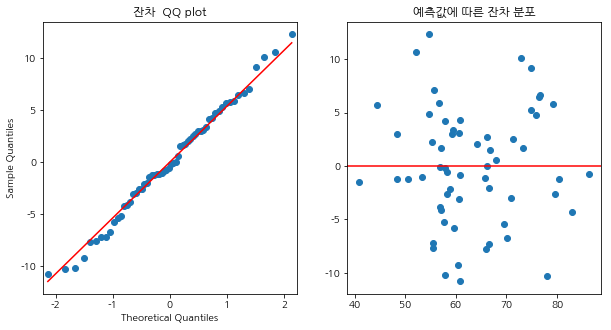

In [399]:
from scipy.stats import shapiro, levene
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

df['resid'] = model.resid

stat1, p1 = shapiro(model.resid)
stat2, p2, _, _ = het_breuschpagan(model.resid, model.model.exog) # 전체 모델의 등분산성 검정
stat2, p2 = levene(*gr)

print(f"잔차의 정규성 검정: {p1:.3f} 정규성", "만족" if p1 >= 0.05 else "불만족")
print(f"잔차의 등분산 검정: {p2:.3f} 등분산성", "만족" if p2 >= 0.05 else "불만족")
print(f"잔차의 독립성 검정: {durbin_watson(model.resid):.3f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

sm.qqplot(model.resid, line='s', ax=ax[0])
ax[1].scatter(model.fittedvalues, model.resid)
ax[0].set_title('잔차  QQ plot')
ax[1].set_title('예측값에 따른 잔차 분포')
ax[1].axhline(y=0, color='r')
plt.show()

정규성, 등분산성을 만족하는 것을 확인할 수 있다. 실험 데이터를 수집하였으므로 독립성은 만족하는 것으로 한다.  
공분산 분석에서의 등분산성 검정은 **변량의 영향을 고려한 등분산성 검정인** Breusch-Pagan 검정이 권장된다. 

다음으로 온라인 교육의 사후점수 효과가 더 높은지 확인하기 위해 조정 평균(Adjusted Means) 비교와 대비분석(Contrast Analysis)을 실시  
- 3그룹+: Bonferroni 보정된 쌍별 비교

In [386]:
# 2그룹: 대비분석
group_coeff = model.params['Learning_Method[T.Traditional]'] #회귀계수
group_se = model.bse['Learning_Method[T.Traditional]'] #표준오차
t_stat = group_coeff / group_se #t 통계량
p_value = model.pvalues['Learning_Method[T.Traditional]'] #p-value
cohens_d = abs(group_coeff) / np.sqrt(model.mse_resid) #효과크기

print(f"- 온라인 vs 전통적 학습: t = {abs(t_stat):.3f}, p = {p_value:.4f}")
print(f"- 전통적 학습이 온라인 교육보다 {group_coeff:.2f} 점 낮음")
print(f"- 표준오차: {group_se:.3f}")
print(f"- 효과크기({cohens_d:.3f}):", "큰효과" if cohens_d > 0.8 else("중간효과" if cohens_d > 0.6 else "작은효과"))

- 온라인 vs 전통적 학습: t = 5.922, p = 0.0000
- 전통적 학습이 온라인 교육보다 -8.48 점 낮음
- 표준오차: 1.432
- 효과크기(1.535): 큰효과


온라인과 전통적 학습의 사후검정 결과이다. 이를 통해서 온라인 학습의 효과가 더 효과적임을 알 수 있다.  

- 회귀계수: Traditional 그룹이 기준그룹(Online)보다 8.482점 낮음
- 표준오차(계수추정의 불확실성): 상대적으로 작은 표준오차 → 정확한 추정
- t-통계량: 매우 큰 효과
  - 기준: |t| > 2 (유의), |t| > 3 (큰 효과), |t| > 5 (매우 큰 효과)
- p-value: 매우 유의함 (p < 0.001)
- ohen's d = 1.535 → 매우 큰 효과

매우 통계적으로 신뢰할 수 있는 검정결과이며, 이를 통해 온라인 학습효과가 더 뛰어남을 알 수 있다. 

In [412]:
gr = [group['Posttest_Score'].values.reshape(-1, 1) for name, group in df.groupby(['Learning_Method'])]
dt = pd.DataFrame(np.concatenate(gr, axis=1), columns=['온라인', '전통적'])

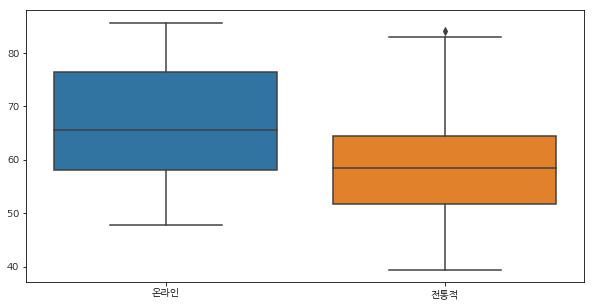

In [413]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=dt)
plt.show()

boxplot으로 온라인 학습의 효과가 더 높음을 시각화하여 확인

# <<비모수검정>>

## 8. McNemar 검정(McNemar’s Test) 

### 1. 정의와 목적  
McNemar 검정은 같은 대상에 대해 **이분형(양/음, 예/아니오) 반응을 두 번 측정**했을 때, 처치 전후 혹은 두 검사법 간의 **분류 일치도 변화**를 검정하는 비모수 통계 기법
- **목적**: 두 관련표본에서 “불일치 셀”의 비대칭이 유의한지를 평가하여, 전후(처치 효과) 또는 검사법 간 차이를 검정  

### 2. 사용 조건 및 가정  
1. **이분형 데이터**  
   - 관찰 결과가 두 범주(예: 성공/실패, 양성/음성)로 구분  
2. **짝을 이루는 관찰**  
   - 동일한 피험자를 두 조건(처치 전·후, 검사 A·B)에서 측정  
3. **셀 빈도**  
   - 불일치 쌍(a→b, b→a)의 합이 충분히 클 것 (전통적 기준: ≥10)  
   - 작을 경우 정확검정(Exact McNemar) 사용  

### 3. 검정 통계량 및 가설  
#### 교차표 구조  

|             | 조건 2: 양성 (+) | 조건 2: 음성 (–) | 합계  |
|:-----------:|:---------------:|:---------------:|:-----:|
| 조건 1: 양성 (+) |      a          |      b          | a + b |
| 조건 1: 음성 (–) |      c          |      d          | c + d |
| **합계**    |   a + c        |   b + d        |  N    |

- **a, d**: 일치 셀 (처치 전후 동일)  
- **b**: “+ → –” 변경 셀  
- **c**: “– → +” 변경 셀  

#### 가설  
- **귀무가설(H₀)**: b = c  (불일치 비율이 대칭)  
- **대립가설(H₁)**: b ≠ c  (비대칭 → 처리·차이 효과 존재)

#### 통계량  
- **카이제곱 근사**  
  $$
    \chi^2 = \frac{(b - c)^2}{b + c}
  $$
  자유도 1, p-value 계산  
- **연속성 보정 (Edwards’ correction)**  
  $$
    \chi^2_\text{corr} = \frac{(|b - c| - 1)^2}{b + c}
  $$
- **정확검정(Exact McNemar)**  
  - b + c가 작을 때, 이항분포를 이용하여 p-value 직접 계산  

### 4. 분석 절차  
1. **데이터 준비**  
   - 짝을 이루는 두 조건에서의 이분형 표본 수 집계  
2. **교차표 작성** (a, b, c, d 도출)  
3. **b + c** 값 확인  
   - ≥10: 근사 검정 사용  
   -  **결론**: 두 조건 간 불일치 방향이 통계적으로 유의하게 다르지 않음.

## 문제 8: 금연 프로그램이 흡연률 변화에 유의한 효과가 있는가?

- 배경: 한국 지역사회 건강센터에서 금연 프로그램의 효과를 평가하려고 한다. 동일한 100명의 흡연자를 대상으로 프로그램 시작 전과  
  완료 후의 흡연 여부를 조사

In [313]:
# === 맥니머 검정: 금연 프로그램 효과 분석 ===
np.random.seed(456)  # 다른 시드로 더 현실적인 데이터 생성
n = 100

# 프로그램 전후 흡연 상태 생성
pre_smoking = np.random.binomial(1, 0.6, n)  # 60% 흡연자
post_smoking = np.zeros(n)

# 각 그룹별로 변화 확률 설정
for i in range(n):
    if pre_smoking[i] == 1:  # 원래 흡연자
        # 70% 확률로 금연 성공
        post_smoking[i] = np.random.binomial(1, 0.3)  
    else:  # 원래 비흡연자
        # 10% 확률로 흡연 시작
        post_smoking[i] = np.random.binomial(1, 0.1)

# 데이터프레임 생성
smoking_data = pd.DataFrame({
    'Subject_ID': range(1, n+1),
    'Pre_Program': pre_smoking,
    'Post_Program': post_smoking
})

# 분할표 생성
contingency = pd.crosstab(smoking_data['Pre_Program'], 
                         smoking_data['Post_Program'], 
                         margins=True, 
                         rownames=['Pre_Program'], 
                         colnames=['Post_Program'])

print("=== 맥니머 검정: 금연 프로그램 효과 분석 ===")
print("분할표 (0: 금연, 1: 흡연):")
display(contingency)

# 2x2 표 추출
mac = contingency.iloc[:2, :2].values
b = mac[0, 1]  # 전 금연 → 후 흡연
c = mac[1, 0]  # 전 흡연 → 후 금연

print(f"\n핵심 데이터:")
print(f"b (전 금연 → 후 흡연): {b}")
print(f"c (전 흡연 → 후 금연): {c}")

=== 맥니머 검정: 금연 프로그램 효과 분석 ===
분할표 (0: 금연, 1: 흡연):


Post_Program,0.0,1.0,All
Pre_Program,,,
0,37,4,41
1,45,14,59
All,82,18,100



핵심 데이터:
b (전 금연 → 후 흡연): 4
c (전 흡연 → 후 금연): 45


한 집단에 대해 어떤 조건의 전/후를 비교하는 이분형 문제이므로 맥니머 검정을 수행한다.  

<가설설정>  
- 귀무: 프로그램 전후 흡연률에 차이가 없다
- 대립: 프로그램 전후 흡연률에 차이가 있다

In [314]:
from statsmodels.stats.contingency_tables import mcnemar
from scipy.stats import chi2

# 맥니머 검정 수행
rs = mcnemar(mac, exact=True)
print(f"\n=== McNemar 검정 결과 ===")
print(f"검정통계량: {rs.statistic:.3f}")
print(f"p-value: {rs.pvalue:.4f}")


=== McNemar 검정 결과 ===
검정통계량: 4.000
p-value: 0.0000


유의수준 5% 하에서 p-value 가 0이므로 귀무가설을 기각할 수 있다.  
따라서, 프로그램 전후 흡연률에 차이가 있다.  

다음으로 오즈비 계산을 통해 효과의 크기를 계산한다.

In [316]:
# 효과크기 (Odds Ratio)
if b > 0 and c > 0: # 담배피기 시작한 사람 & 담배 끊은 사람
    odds_ratio = c / b # 담배 끊은 사람/피기 시작한 사람 비율
    print(f"\n=== 효과크기 ===")
    print(f"- Odds Ratio: {odds_ratio:.3f}")
    print(f"- 해석: 금연 성공이 재흡연보다 {odds_ratio:.1f}배 더 일어나기 쉽다")
    
    # 95% 신뢰구간
    ln_or = np.log(odds_ratio)
    se_ln_or = np.sqrt(1/b + 1/c)
    ci_lower = np.exp(ln_or - 1.96 * se_ln_or)
    ci_upper = np.exp(ln_or + 1.96 * se_ln_or)
    print(f"- 95% 신뢰구간: [{ci_lower:.3f}, {ci_upper:.3f}]")


=== 효과크기 ===
- Odds Ratio: 11.250
- 해석: 금연 성공이 재흡연보다 11.2배 더 일어나기 쉽다
- 95% 신뢰구간: [4.046, 31.281]


## 9. 크루스칼–왈리스 검정(Kruskal–Wallis Test)

### 1. 정의와 목적  
**크루스칼–왈리스 검정**은 서로 독립인 세 개 이상의 집단 간에 **연속형 또는 서열형 자료**의 분포 차이를 비모수적으로 검정하는 방법
- **목적**: 집단 간 중앙값(혹은 분포 전체)이 동일한지 여부를 검정  
- **대안**: 일원배치 ANOVA의 비모수적 대응 검정  

### 2. 사용 조건 및 가정  
1. **독립표본**  
   - 각 집단의 관측치는 서로 독립적이어야 함  
2. **측정 척도**  
   - 종속변수는 서열(순위) 또는 연속형 자료  
3. **분포 형태**  
   - 각 집단의 분포 형태가 유사(모양 동일)하고 위치(location)만 차이  
   - 모양이 크게 다를 경우 해석 제한  

### 3. 검정 통계량 및 가설  
#### 절차  
1. 모든 관측값을 하나의 공통 집합으로 합친 뒤 오름차순으로 **순위(rank)** 부여  
2. 각 집단별 순위 합계 $R_i$ 계산  
3. 각 집단 크기 $n_i$ 확인  

#### 통계량  
$$
H = \frac{12}{N(N+1)} \sum_{i=1}^k \frac{R_i^2}{n_i} \;-\; 3(N+1)
$$  

- $k$: 집단 수  
- $N=\sum n_i$: 전체 표본 수  
- $R_i$: 집단 $i$의 순위 합계  
- 연속 순위가 동일값(ties) 존재 시 보정 적용  

#### 가설  
- **$H_0$**: 모든 집단의 분포(중앙값)가 동일  
- **$H_1$**: 적어도 하나의 집단 중앙값이 다름  

- 귀무가설 기각 기준:  
  - $H$가 카이제곱 분포 $\chi^2_{k-1}$의 임계값보다 크거나, p-value  사후검정 시 다중비교 보정(예: Bonferroni, Holm)을 적용하여 1종 오류 통제

### 5. 분석 절차  
1. 데이터 준비 및 독립 표본 확인  
2. 순위 부여 및 순위 합계 계산  
3. $H$ 통계량 산출(및 동률 보정)  
4. 카이제곱 분포 기반 p-value 계산  
5. 귀무가설 판단(유의 여부)  
6. 유의 시 사후검정으로 집단 간 차이 파악  

## 문제9: 의료 분야 예제: 통증 완화 효과 비교 (비정규 분포 데이터)

**【연구 배경】**
한 재활의학과에서 만성 요통 환자를 대상으로 세 가지 치료법의 통증 완화 효과를 비교

**【치료법】**
1. 물리치료 (Physical Therapy)
2. 침술 (Acupuncture)
3. 마사지 요법 (Massage Therapy)

**【측정】**
- VAS (Visual Analog Scale) 통증 점수 (0-10점)
- 치료 4주 후 통증 감소량
- 각 그룹 25명씩 총 75명

In [282]:
# 비정규 분포 데이터 생성 (현실적인 통증 데이터)
np.random.seed(42)
n_per_treatment = 25

# 치료법별로 서로 다른 중앙값을 가지도록 분포 매개변수 조정
physical_therapy = np.random.gamma(shape=2, scale=2, size=n_per_treatment)  # 평균 ~4
acupuncture = np.random.exponential(scale=1.5, size=n_per_treatment)  # 평균 ~1.5  
massage = np.random.lognormal(mean=1.5, sigma=0.5, size=n_per_treatment)  # 평균 ~4.8

# VAS 점수 범위로 조정 (0-10)
physical_therapy = np.clip(physical_therapy, 0, 10)
acupuncture = np.clip(acupuncture, 0, 10)
massage = np.clip(massage, 0, 10)

# 데이터프레임 생성
pain_data = np.concatenate([physical_therapy, acupuncture, massage])
treatment_labels = (
    ['Physical_Therapy'] * n_per_treatment + 
    ['Acupuncture'] * n_per_treatment + 
    ['Massage'] * n_per_treatment
)

df_pain = pd.DataFrame({'Pain_Reduction': pain_data, 'Treatment': treatment_labels})

print("\n치료법별 기술통계:")
pain_stats = df_pain.groupby('Treatment')['Pain_Reduction'].agg([
'count', 'mean', 'median', 'std', 'min', 'max'
]).round(2)
display(pain_stats)

display(df_pain.head())


치료법별 기술통계:


,count,mean,median,std,min,max
Treatment,,,,,,
Acupuncture,25,1.32,0.67,1.45,0.01,6.5
Massage,25,5.11,4.68,2.42,1.21,9.8
Physical_Therapy,25,3.58,2.99,2.24,0.43,9.3


,Pain_Reduction,Treatment
0,4.787359,Physical_Therapy
1,2.988929,Physical_Therapy
2,2.764567,Physical_Therapy
3,2.764605,Physical_Therapy
4,9.299429,Physical_Therapy


크루스칼 왈리스 검정은 One-way ANOVA의 대안인 비모수 검정기법으로 모수검정의 가정사항을 만족하지 못할 시 사용한다.  
정규성 만족여부를 확인한다. 아래의 결과를 보면 2개 그룹만이 정규성을 만족한다. 따라서 비모수검정을 실시한다.

In [310]:
print(f"\n=== 정규성 검정 (Shapiro-Wilk) ===")
rs = {}
for treatment in df_pain['Treatment'].unique():
    treatment_data = df_pain[df_pain['Treatment'] == treatment]['Pain_Reduction']
    stat, p = shapiro(treatment_data)
    rs[treatment] = p
    print(f"- {treatment}: W = {stat:.4f}, p = {p:.4f} {'(정규)' if p > 0.05 else '(비정규)'}")
all_normal = all(p > 0.05 for p in rs.values())
print(f"\n- 모든 그룹 정규성 만족: {'예' if all_normal else '아니오'}")


=== 정규성 검정 (Shapiro-Wilk) ===
- Physical_Therapy: W = 0.9208, p = 0.0534 (정규)
- Acupuncture: W = 0.7826, p = 0.0001 (비정규)
- Massage: W = 0.9341, p = 0.1078 (정규)

- 모든 그룹 정규성 만족: 아니오


<가설 설정>  
- 귀무: 모든 치료법의 통증점수 분포가 동일하다.
- 대립: 적어도 하나의 치료법의 통증점수 분포가 다르다.

In [284]:
from scipy.stats import kruskal

groups = [df_pain.loc[df_pain['Treatment']==g, 'Pain_Reduction'] for g in df_pain['Treatment'].unique()]
stat, p = kruskal(*groups)
print(f"Kruskal–Wallis 통계량={stat:.3f}, p={p:.3f}")

Kruskal–Wallis 통계량=33.722, p=0.000


p-value가 0이므로 유의수준 5% 하에서 귀무가설을 기각한다.
**따라서 적어도 하나의 치료법의 통증점수 분포가 다르다.**  

어느 그룹 간 통증점수 분포 차이가 존재하는 지 확인하기 위해  
사후검정인 윌콕슨 순위합 검정 또는 Dunn’s 사후검정을 실시하여 통증점수 차이가 유의한 집단을 확인할 수 있다.

In [293]:
# 사후검정
col_comp = [[groups[0], groups[1]], [groups[0], groups[2]], [groups[1], groups[2]]]
title = [['Physical_Therapy', 'Acupuncture'], ['Physical_Therapy', 'Massage'], ['Acupuncture', 'Massage']]

from scipy.stats import ranksums

alpha_bonf = 0.05 / 3 #제1종 오류 증가: 3번의 쌍별 비교를 α=0.05로 각각 검정하면, 
                      #전체적으로 제1종 오류율이 약 14.3% (1-(0.95)³)로 증가

for (g1, g2), tt in zip(col_comp, title):
    stat, p = ranksums(g1, g2)
    print(f"\n<{tt[0]} - {tt[1]} 순위합 검정(사후)>")
    print(f"- 검정통계량: {stat} / p-value: {p:.3f}", "***" if p <= alpha_bonf  else '')
    print(f"- 유의수준 5% 하 p-value {p:.3f} 이므로 귀무가설을 기각할 수", "있다." if p <= alpha_bonf else "없다.")


<Physical_Therapy - Acupuncture 순위합 검정(사후)>
- 검정통계량: 4.161911325623474 / p-value: 0.000 ***
- 유의수준 5% 하 p-value 0.000 이므로 귀무가설을 기각할 수 있다.

<Physical_Therapy - Massage 순위합 검정(사후)>
- 검정통계량: -2.33804342535025 / p-value: 0.019 
- 유의수준 5% 하 p-value 0.019 이므로 귀무가설을 기각할 수 없다.

<Acupuncture - Massage 순위합 검정(사후)>
- 검정통계량: -5.2872766257920585 / p-value: 0.000 ***
- 유의수준 5% 하 p-value 0.000 이므로 귀무가설을 기각할 수 있다.


In [286]:
import scikit_posthocs as sp

# Kruskal–Wallis 이후 Dunn’s 사후검정 (Bonferroni 보정)
print("\n=== Dunn's 사후검정 (Bonferroni 보정) ===")
dunn_results = sp.posthoc_dunn(df_pain,
                               val_col='Pain_Reduction',
                               group_col='Treatment',
                               p_adjust='bonferroni')
print("사후검정 결과 (p-values):")
display(dunn_results.round(4))


=== Dunn's 사후검정 (Bonferroni 보정) ===
사후검정 결과 (p-values):


,Acupuncture,Massage,Physical_Therapy
Acupuncture,1.0000,0.0000,0.0005
Massage,0.0000,1.0000,0.1571
Physical_Therapy,0.0005,0.1571,1.0000


다음은 Dunn’s 사후검정 결과(p-값, Bonferroni 보정)

| 비교                                   | p-값    | 해석                         |
|:--------------------------------------|:--------|:-----------------------------|
| Acupuncture vs. Massage               | 0  | 유의함 (p < 0.05)     |
| Acupuncture vs. Physical_Therapy      | 0.0005  | 유의함 (p < 0.05)     |
| Massage vs. Physical_Therapy          | 0.1571  | 유의하지 않음 (p > 0.05)     |


Massage vs. Physical_Therapy 를 제외한 치료법 쌍 간 통증점수 차이가 유의하다.   
- 마사지-침술 간 통증점수 차이 있음
- 침술-물리치료 간 통증점수 차이 있음
- 마사지-물리치료 통증점수 차이 없음

만약 사후검정 결과가 유의하다면 효과크기 계산을 수행

In [294]:
# 2) 표본 크기와 그룹 수
n = len(df_pain)
k = df_pain['Treatment'].nunique()

# 3) epsilon-squared 계산 (올바른 공식)
epsilon_squared = (stat - k + 1) / (n - k)
epsilon_squared = max(0, epsilon_squared)  # 음수 방지

# 4) 효과 크기 해석 (올바른 기준값)
if epsilon_squared < 0.01:
    effect_interpretation = "작은 효과"
elif epsilon_squared < 0.06:
    effect_interpretation = "중간 효과"  
else:
    effect_interpretation = "큰 효과"

# 5) 출력
print(f"\n효과크기 (Epsilon-squared): ε² = {epsilon_squared:.4f}")
print(f"해석: {effect_interpretation}")


효과크기 (Epsilon-squared): ε² = 0.0000
해석: 작은 효과


ε² 해석: 전체 변동 중 그룹 차이로 설명되는 비율을 의미

- 0에 가까우면 그룹 간 차이 없음
- 1에 가까우면 완전한 그룹 의존성

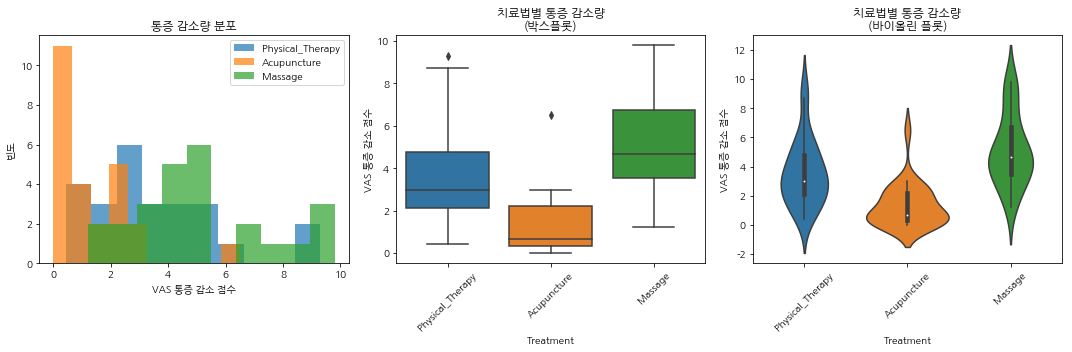

In [302]:
# 분포 시각화
plt.figure(figsize=(15, 5))

# 히스토그램
plt.subplot(1, 3, 1)
for i, treatment in enumerate(df_pain['Treatment'].unique()):
    treatment_data = df_pain[df_pain['Treatment'] == treatment]['Pain_Reduction']
    plt.hist(treatment_data, alpha=0.7, label=treatment, bins=10)
plt.title('통증 감소량 분포')
plt.xlabel('VAS 통증 감소 점수')
plt.ylabel('빈도')
plt.legend()

# 박스플롯
plt.subplot(1, 3, 2)
sns.boxplot(data=df_pain, x='Treatment', y='Pain_Reduction')
plt.title('치료법별 통증 감소량\n(박스플롯)')
plt.xticks(rotation=45)
plt.ylabel('VAS 통증 감소 점수')
# 바이올린 플롯
plt.subplot(1, 3, 3)
sns.violinplot(data=df_pain, x='Treatment', y='Pain_Reduction')
plt.title('치료법별 통증 감소량\n(바이올린 플롯)')
plt.xticks(rotation=45)
plt.ylabel('VAS 통증 감소 점수')
plt.tight_layout()
plt.show()

마사지, 물리치료 두 가지 치료법이 통증점수 감소에 효과가 있었다. 두 치료법 간 통증감소 차이는 통계적으로 유의하지 않았지만  
중위값 기준(50%의 환자)으로 보았을 때는 마사지의 통증감소 점수가 더 높았으므로 치료비용이 비슷하거나 더 저렴하다면  
마사지를 통한 치료를 채택한다.

## 10. 프리드먼 검정(Friedman Test)

### 1. 정의와 목적  
프리드먼 검정은 **세 개 이상의 관련표본(반복 측정)** 에 대해 이분산성(비모수)을 가정하고 **순위 비교**를 통해 집단 간 차이를 검정하는 방법  
- **목적**: 동일 대상이 여러 조건·시점에서 받은 점수의 중앙값(순위 평균)이 모두 같은지 검정  
- **대안**: 일원 반복측정 ANOVA의 비모수 대응 검정  

### 2. 사용 조건 및 가정  
1. **반복 측정 설계**  
   - 동일 피험자가 $k$개 조건(또는 시점)에서 측정  
2. **서열 또는 연속형 자료**  
   - 데이터가 순위화 가능해야 함  
3. **측정치 독립성(블록 독립성)**  
   - 서로 다른 피험자(블록) 간 관측치는 독립  
4. **조건 간 분포 형태**  
   - 분포 모양은 비슷하되 위치(location)만 차이  

### 3. 검정 통계량 및 가설  
#### 절차  
1. 각 피험자(블록)별 $k$개 조건값에 대해 **순위(rank)** 부여  
2. 조건 $j$의 순위 합계 $R_j$ 계산  
3. 전체 관측치 수 $N$, 조건 수 $k$ 확인  

#### 통계량  
$$
\chi^2_F = \frac{12}{Nk(k+1)} \sum_{j=1}^k R_j^2 \;-\; 3N(k+1)
$$  
- $N$: 블록 수(피험자 수)  
- $k$: 조건 수  
- $R_j$: 조건 $j$의 순위 합계  

- **동률 보정(ties)**: 동일값 순위평균으로 순위 부여 후, 분모에 보정항 추가  

#### 가설  
- **$H_0$**: 모든 조건의 순위 중앙값(또는 평균 순위)이 동일  
- **$H_1$**: 적어도 하나 조건의 순위 중앙값이 다름  

- 귀무가설 기각 기준: $\chi^2_F$가 자유도 $k-1$인 카이제곱 분포 임계값 초과 또는 p-value  사후검정 시 다중비교 보정(α/m 적용)으로 1종 오류 통제

### 5. 분석 절차  
1. 데이터 준비: $N$명 × $k$조건 자료  
2. 가정 확인: 블록 독립성, 분포 모양 유사성  
3. 순위 부여 및 $R_j$ 계산  
4. $\chi^2_F$ 통계량 산출  
5. p-value 해석(자유도 $k-1$)  
6. 사후검정으로 조건별 차이 파악  


## 문제 10: 세 치료법 간에 통증 감소 효과의 차이가 있는가?

- 배경: 정형외과에서 무릎 관절염 환자 20명을 대상으로 세 가지 치료법(물리치료, 약물치료, 침술치료)의 효과를 비교함.   
  각 환자는 3주간에 걸쳐 세 치료를 모두 받으며, 매주 통증 점수(VAS: 0-10점)를 측정

한 집단을 대상으로 조건에 따라 반복측정을 수행하였으므로, 모수 분산분석인 일원배치 anova를 적용할 수 있으며, anova 의 가정조건인  
정규성, 구형성, 독립성을 만족하지 못한다면 비모수 기법인 프리드만 검정을 사용할 수 있다. 

In [322]:
np.random.seed(456)
np.random.seed(789)  # 비정규성을 위한 다른 시드
n_patients = 20

patients = []
for i in range(n_patients):
    baseline_pain = np.random.uniform(6, 9)
    
    # 비정규 분포 생성 (감마분포, 지수분포 등 사용)
    physical_therapy = np.random.gamma(2, 1.5) + 2  # 감마분포
    medication = np.random.exponential(2) + 1       # 지수분포  
    acupuncture = np.random.lognormal(0.5, 0.8) + 0.5  # 로그정규분포
    
    # 0-10 범위로 제한하되 치료 효과 차이를 명확히
    physical_therapy = np.clip(physical_therapy, 0, 10)
    medication = np.clip(medication * 0.8, 0, 10)  # 더 효과적
    acupuncture = np.clip(acupuncture * 0.6, 0, 10)  # 가장 효과적
    
    patients.append({
        'Patient_ID': i+1,
        'Physical_Therapy': round(physical_therapy, 1),
        'Medication': round(medication, 1),
        'Acupuncture': round(acupuncture, 1)
    })

pain_data = pd.DataFrame(patients)

print("통증 치료법 비교 데이터:")
display(pain_data.head(10))

print(f"\n치료법별 기술통계:")
display(pain_data[['Physical_Therapy', 'Medication', 'Acupuncture']].describe().round(2).T)

통증 치료법 비교 데이터:


,Patient_ID,Physical_Therapy,Medication,Acupuncture
0,1,6.1,6.7,0.9
1,2,4.7,2.1,0.7
2,3,7.1,1.2,0.8
3,4,3.2,2.2,0.5
4,5,8.1,1.9,1.7
5,6,7.6,1.2,1.3
6,7,5.1,1.2,1.0
7,8,5.9,2.5,1.7
8,9,2.5,1.2,2.1
9,10,2.2,4.3,2.8



치료법별 기술통계:


,count,mean,std,min,25%,50%,75%,max
Physical_Therapy,20.0,5.31,1.99,2.2,3.85,5.00,6.50,9.7
Medication,20.0,2.30,1.37,0.9,1.20,2.05,2.52,6.7
Acupuncture,20.0,1.42,0.86,0.5,0.80,1.25,1.78,3.6


In [325]:
print(f"\n=== 정규성 검정 (Shapiro-Wilk) ===")
rs = {}
for col in pain_data.columns:
    dt = pain_data[col]
    stat, p = shapiro(dt)
    rs[col] = p
    print(f"- {col}: W = {stat:.4f}, p = {p:.4f} {'(정규)' if p > 0.05 else '(비정규)'}")
all_normal = all(p > 0.05 for p in rs.values())
print(f"\n- 모든 그룹 정규성 만족: {'예' if all_normal else '아니오(프리드먼 검정 실시)'}")


=== 정규성 검정 (Shapiro-Wilk) ===
- Patient_ID: W = 0.9604, p = 0.5514 (정규)
- Physical_Therapy: W = 0.9775, p = 0.8980 (정규)
- Medication: W = 0.8126, p = 0.0013 (비정규)
- Acupuncture: W = 0.8731, p = 0.0133 (비정규)

- 모든 그룹 정규성 만족: 아니오(프리드먼 검정 실시)


In [330]:
from scipy.stats import shapiro, levene, friedmanchisquare
import pingouin as pg

def choose_test_method(data, groups):
    
    print("=== 검정 방법 선택을 위한 가정 확인 ===")
    
    # 1단계: 데이터 특성 확인 (수정된 부분)
    data_types = [str(data[group].dtype) for group in groups]
    is_continuous = all('float' in dtype or 'int' in dtype for dtype in data_types)
    
    print(f"1. 데이터 척도: {'연속형' if is_continuous else '서열형'}")
    print(f"2. 표본 크기: {len(data)}")
    
    # 2단계: 정규성 검정
    normality_results = {}
    for group in groups:
        stat, p = shapiro(data[group])
        normality_results[group] = p > 0.05
        print(f"3. {group} 정규성: p={p:.4f} {'✓' if p > 0.05 else '✗'}")
    
    all_normal = all(normality_results.values())
    
    # 3단계: 구형성 검정 (정규성 만족 시에만)
    sphericity_ok = True
    if all_normal and len(groups) > 2:
        print("4. 구형성: 반복측정 ANOVA 적합 시 Mauchly's test 필요")
    
    # 4단계: 이상값 확인
    has_outliers = False
    for group in groups:
        Q1, Q3 = data[group].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        outliers = ((data[group] < Q1 - 1.5*IQR) | (data[group] > Q3 + 1.5*IQR)).sum()
        if outliers > 0:
            has_outliers = True
            print(f"5. {group} 이상값: {outliers}개")
    
    if not has_outliers:
        print("5. 이상값: 없음")
    
    # 5단계: 권장 검정 방법 결정
    print("\n=== 권장 검정 방법 ===")
    
    if all_normal and not has_outliers and len(data) >= 20 and is_continuous:
        recommendation = "반복측정 ANOVA (구형성 추가 확인 필요)"
        reason = "정규성 만족, 충분한 표본, 이상값 없음"
    elif not all_normal:
        recommendation = "프리드먼 검정"
        reason = "정규성 가정 위배"
    elif has_outliers:
        recommendation = "프리드먼 검정"
        reason = "이상값 존재로 인한 강건성 필요"
    elif not is_continuous:
        recommendation = "프리드먼 검정"
        reason = "서열형 데이터"
    else:
        recommendation = "프리드먼 검정"
        reason = "작은 표본 크기 또는 기타 가정 위배"
    
    print(f"권장: {recommendation}")
    print(f"이유: {reason}")
    
    return recommendation

# 사용 예시
recommendation = choose_test_method(pain_data, ['Physical_Therapy', 'Medication', 'Acupuncture'])

=== 검정 방법 선택을 위한 가정 확인 ===
1. 데이터 척도: 연속형
2. 표본 크기: 20
3. Physical_Therapy 정규성: p=0.8980 ✓
3. Medication 정규성: p=0.0013 ✗
3. Acupuncture 정규성: p=0.0133 ✗
5. Medication 이상값: 1개
5. Acupuncture 이상값: 1개

=== 권장 검정 방법 ===
권장: 프리드먼 검정
이유: 정규성 가정 위배


반복측정 그룹별 데이터의 정규성을 만족하지 못하므로 비모수 방식인 프리드먼 검정을 실시한다.  

<가설설정>  
- 귀무: 세 치료법의 통증 감소 효과에 차이가 없다
- 대립: 적어도 하나의 치료법이 다른 효과를 보인다

In [332]:
from scipy.stats import friedmanchisquare

groups = [pain_data[col] for col in pain_data.columns[1:]]

# 프리드먼 검정 수행
friedman_stat, p_value = friedmanchisquare(*groups)

print(f"\n프리드먼 검정 결과:")
print(f"- 검정 통계량: {friedman_stat:.3f}")
print(f"- p-value: {p_value:.4f}")


프리드먼 검정 결과:
- 검정 통계량: 23.700
- p-value: 0.0000


검정결과 유의수준 5% 하에서 p-value가 0이므로 귀무가설을 기각한다.  
따라서 적어도 하나의 치료법이 다른 효과를 보인다는 대립가설은 통계적으로 유의하다.   

다음으로 사후검정을 실시하여 어떤 치료법이 효과를 보이는지를 확인한다. 윌콕슨 부호순위 검정을 통해 확인할 수 있다. 

In [347]:
# 사후검정: 윌콕슨 부호검정
from itertools import combinations

col_comp = list(combinations(groups, 2)) #2개씩 쌍

from scipy.stats import wilcoxon

# Bonferroni 보정
alpha_bonf = 0.05 / len(col_comp)
print(f"Bonferroni 보정 α = {alpha_bonf:.4f} (총 {len(col_comp)}회 비교)")

for group in col_comp:
    stat, p = wilcoxon(*group, zero_method='wilcox')
    print(f"- {group[0].name} - {group[1].name} 검정통계량: {stat} / p-value: {p:.3f}", "***" if p <= alpha_bonf else '')    

Bonferroni 보정 α = 0.0167 (총 3회 비교)
- Physical_Therapy - Medication 검정통계량: 8.0 / p-value: 0.000 ***
- Physical_Therapy - Acupuncture 검정통계량: 3.0 / p-value: 0.000 ***
- Medication - Acupuncture 검정통계량: 48.0 / p-value: 0.033 


윌콕슨 부호순위 검정을 통해 각 치료법 간 통증감소 효과 차이를 비교하였다.  

- 물리치료-약물치료: 통증감소 차이 유의함
- 물리치료-침술치료: 통증감소 차이 유의함
- 약물치료-침술치료: 통증감소 차이 없음

따라서, 약물치료와 침술치료 모두 통증감소 차이가 있으며 두 치료법의 효능 차이는 통계적으로 유의하지 않다.

In [352]:
print(f"\n=== 치료법별 평균 순위 ===")
rank_data = pain_data[pain_data.columns[1:]].rank(axis=1)
mean_ranks = rank_data.mean().sort_values()

for i, (treatment, mean_rank) in enumerate(mean_ranks.items(), 1):
    print(f"{i}위. {treatment}: {mean_rank:.2f}")

print(f"\n* 순위가 낮을수록 더 나은 치료법 (점수가 낮음)")


=== 치료법별 평균 순위 ===
1위. Acupuncture: 1.35
2위. Medication: 1.80
3위. Physical_Therapy: 2.85

* 순위가 낮을수록 더 나은 치료법 (점수가 낮음)


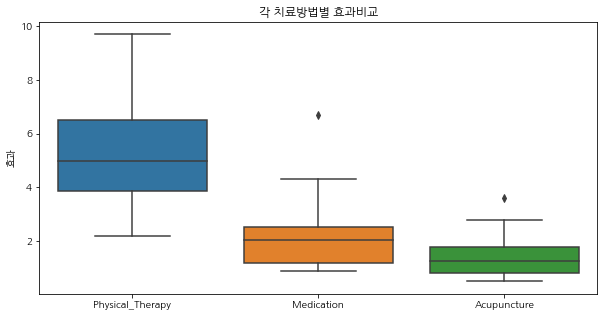

In [363]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=pain_data.iloc[:, 1:])
plt.title("각 치료방법별 효과비교")
plt.ylabel('효과')
plt.show()

시각화로 확인했을 때도 약물과 침술치료 시 통증점수가 낮아진 것을 확인할 수 있으며, 중앙값(환자의 50% 분위수)을 기준으로 보았을 때는  
침술의 효과가 더 좋아보인다. 따라서 치료비용의 차이가 크지 않다면 침술로 치료하는 것을 고려할 수 있다. 